In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, LabelBinarizer, StandardScaler, OneHotEncoder
from sklearn.feature_selection import f_classif
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error

### BUSINESS QUESTION: What factors determine house prices, and how can we accurately predict them?
### ANALYTICAL QUESTION: How do features like size, location, and condition influence price?
### HYPOTHESIS: Larger houses → higher price; Location significantly impacts price; Age negatively affects price
### create a contigency table or check for relationship (using either tests or plots) between categorical values and the target

In [3]:
data = pd.read_csv("data/AmesHousing.csv")

In [5]:
data.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [7]:
data.shape

(2930, 82)

In [9]:
for col in data.columns:
    if data[col].count() < 1000:  # Count non-null values
        data.drop(col, axis=1, inplace=True)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 78 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Lot Shape        2930 non-null   object 
 8   Land Contour     2930 non-null   object 
 9   Utilities        2930 non-null   object 
 10  Lot Config       2930 non-null   object 
 11  Land Slope       2930 non-null   object 
 12  Neighborhood     2930 non-null   object 
 13  Condition 1      2930 non-null   object 
 14  Condition 2      2930 non-null   object 
 15  Bldg Type        2930 non-null   object 
 16  House Style      2930 non-null   object 
 17  Overall Qual  

In [8]:
data['Sale Type'].value_counts()

Sale Type
WD       2536
New       239
COD        87
ConLD      26
CWD        12
ConLI       9
ConLw       8
Oth         7
Con         5
VWD         1
Name: count, dtype: int64

In [9]:
data['Sale Condition'].value_counts()

Sale Condition
Normal     2413
Partial     245
Abnorml     190
Family       46
Alloca       24
AdjLand      12
Name: count, dtype: int64

In [10]:
data['MS Zoning'].value_counts()

MS Zoning
RL         2273
RM          462
FV          139
RH           27
C (all)      25
I (all)       2
A (agr)       2
Name: count, dtype: int64

In [11]:
data['Fireplace Qu'].value_counts()

Fireplace Qu
Gd    744
TA    600
Fa     75
Po     46
Ex     43
Name: count, dtype: int64

In [12]:
data.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


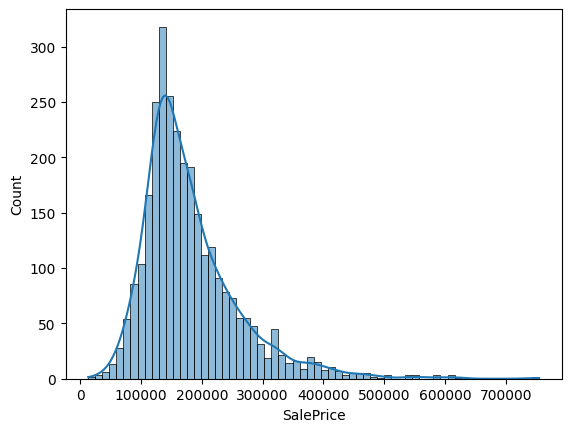

In [13]:
sns.histplot(data,x=data['SalePrice'], kde=True)
plt.show()

In [14]:
data['SalePrice'] = np.log1p(data['SalePrice'])

In [15]:
data.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,12.278398
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,11.561725
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,12.055256
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,12.404928
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,12.154258


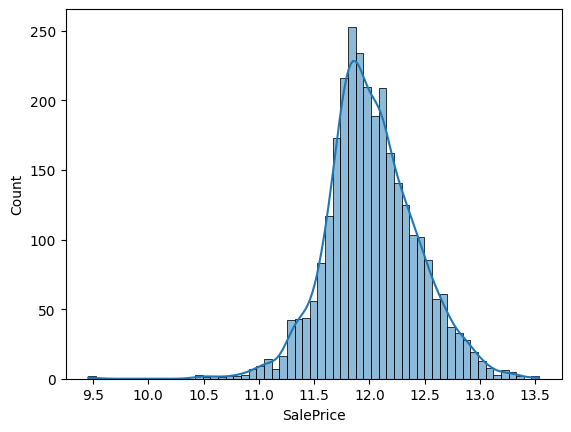

In [16]:
sns.histplot(data,x=data['SalePrice'], kde=True)
plt.show()

### FEATURE EXPLORATION

In [19]:
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = numerical_cols.drop(['Order', 'PID', 'SalePrice'])
categorical_cols = data.select_dtypes(include=['object']).columns

In [20]:
num_corr = data[numerical_cols].corr()

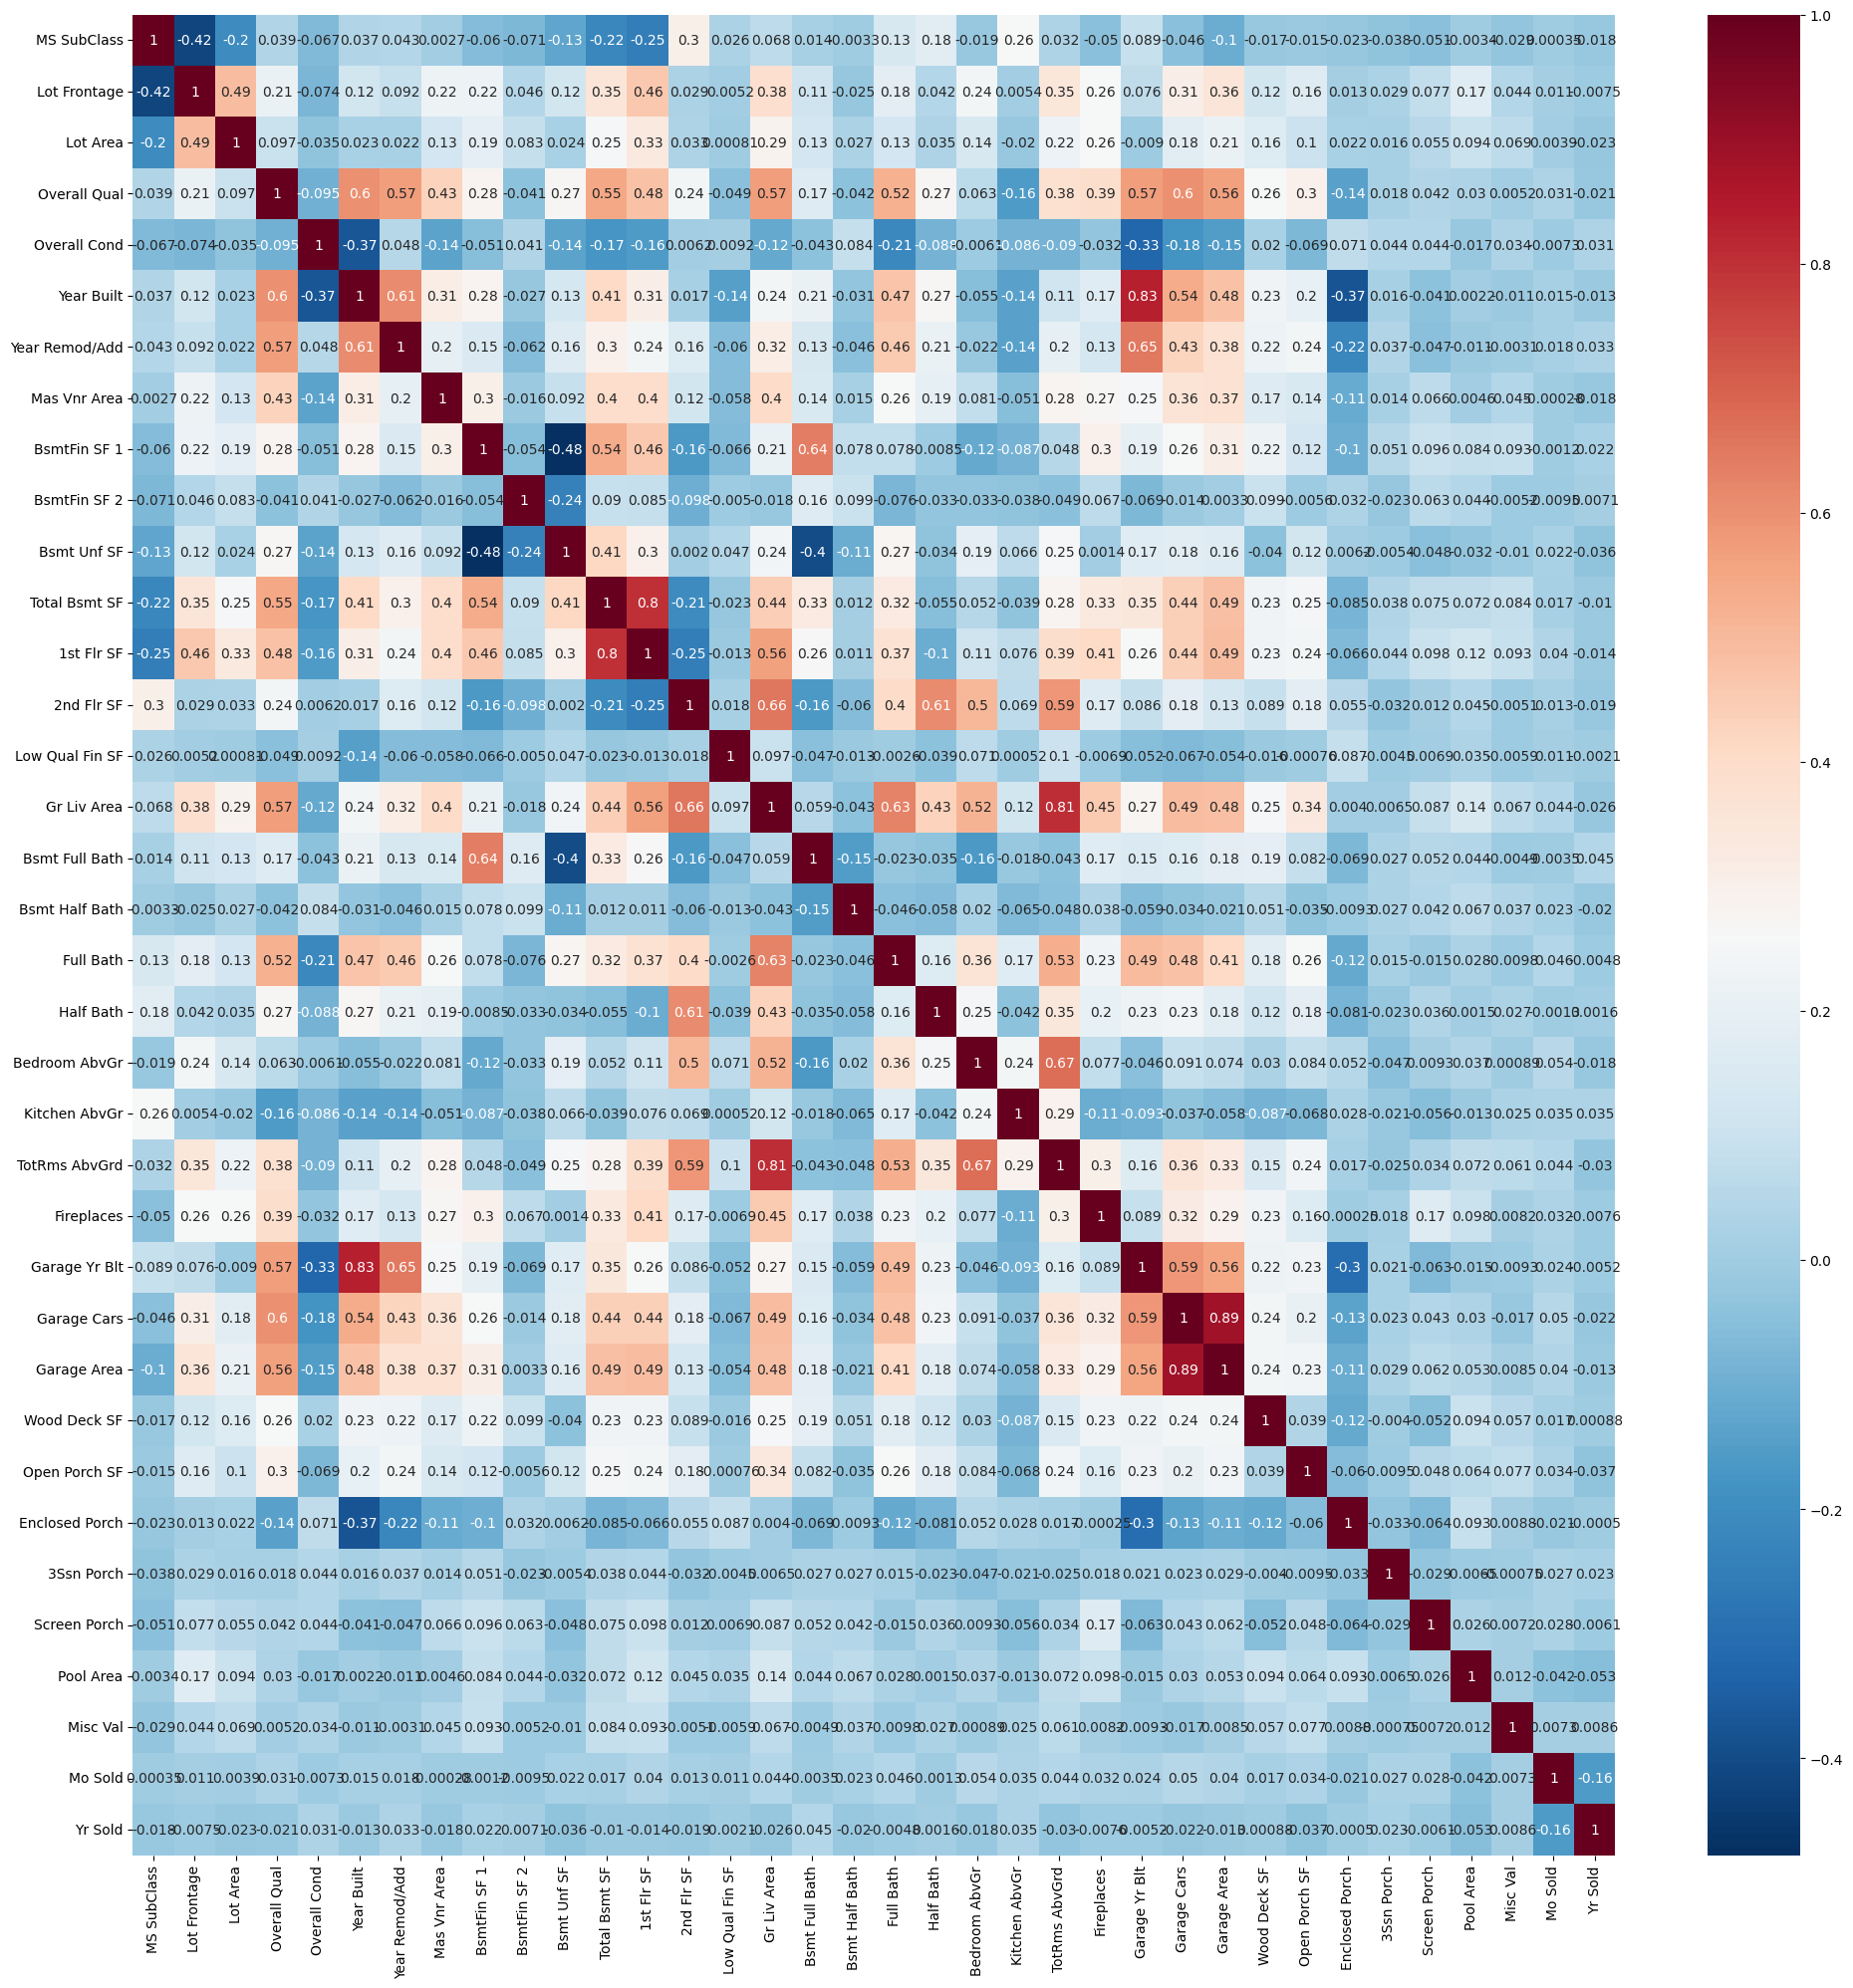

In [21]:
plt.figure(figsize=(24,24))
sns.heatmap(num_corr, annot=True, cmap='RdBu_r')

plt.show()

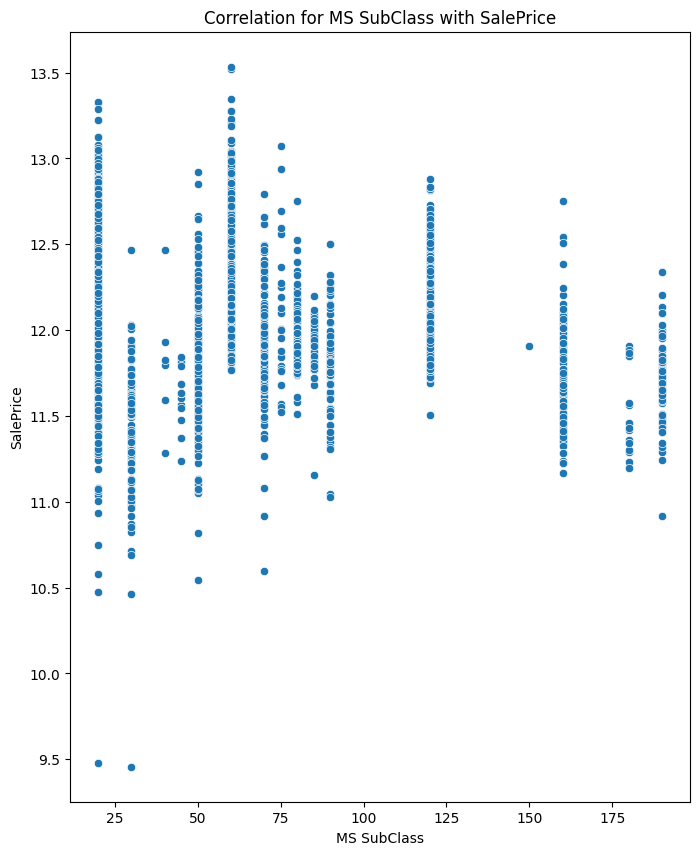

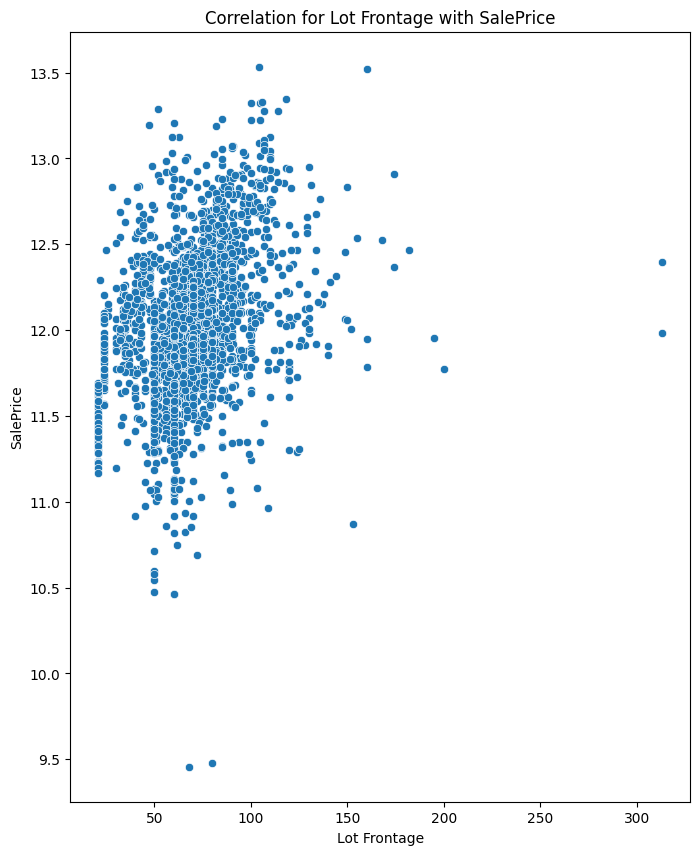

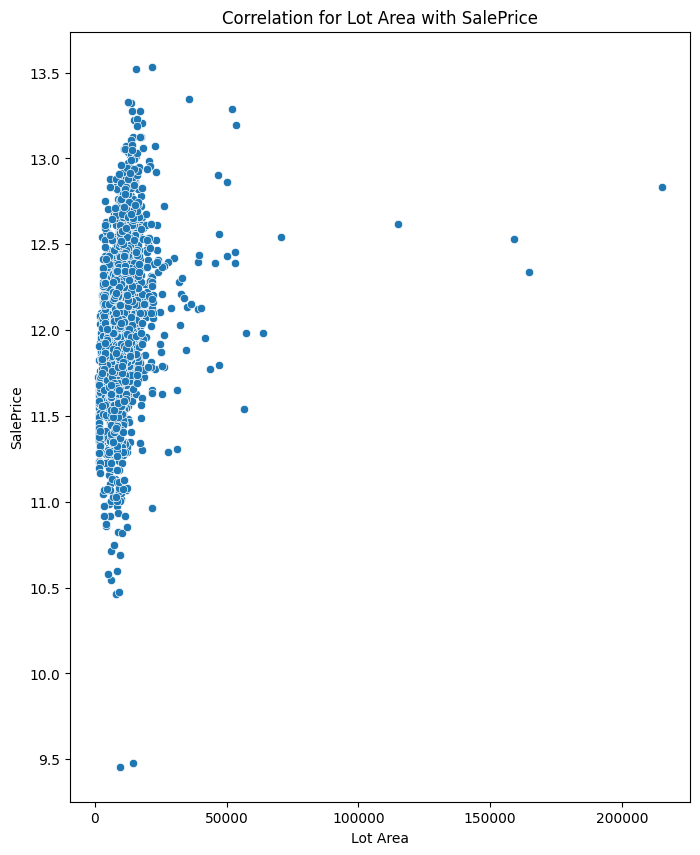

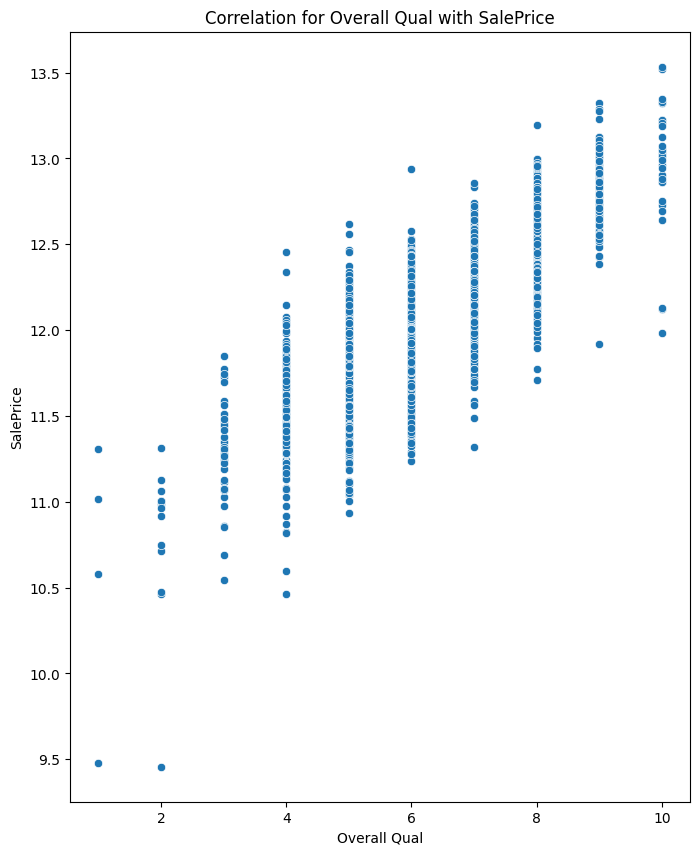

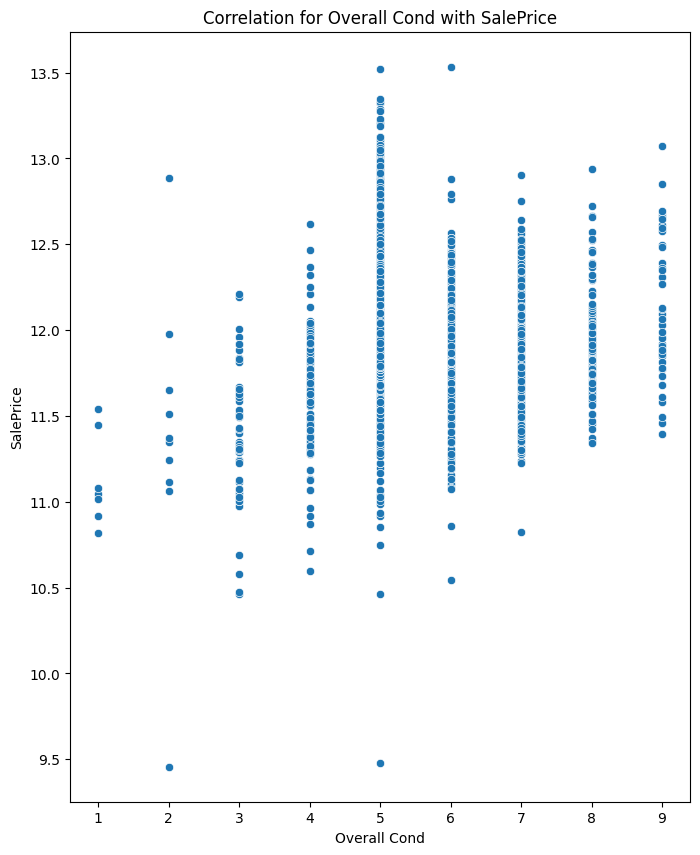

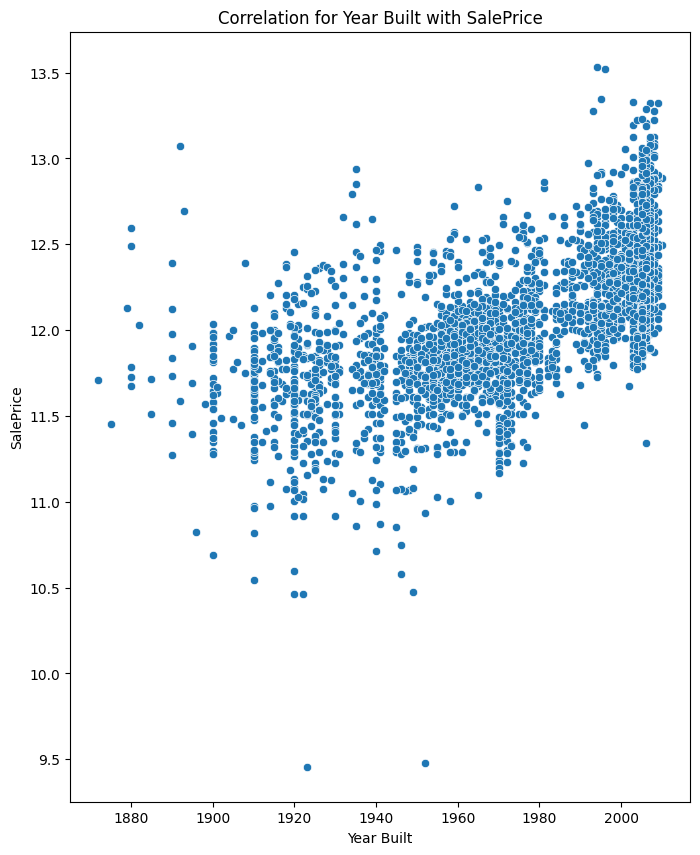

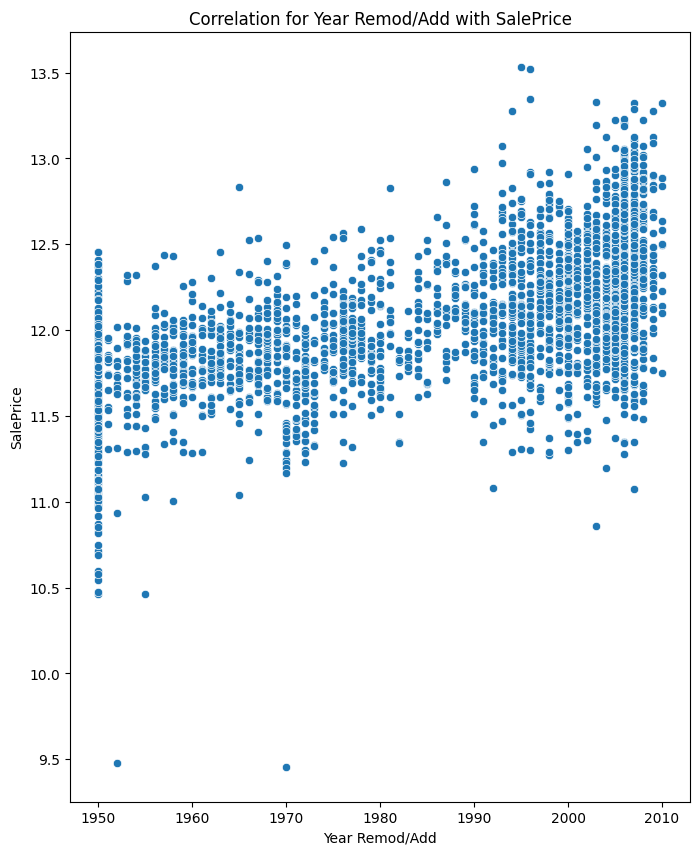

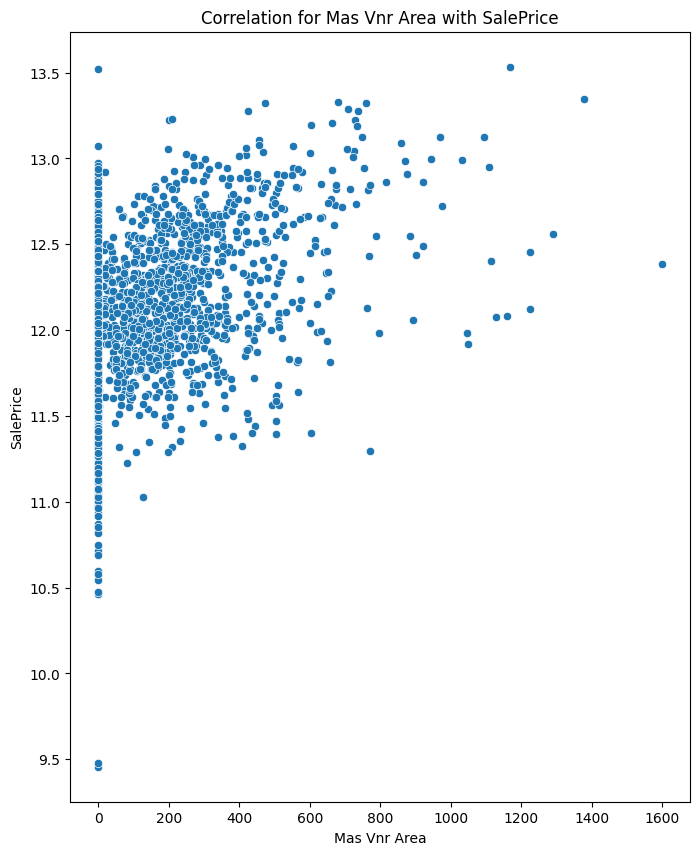

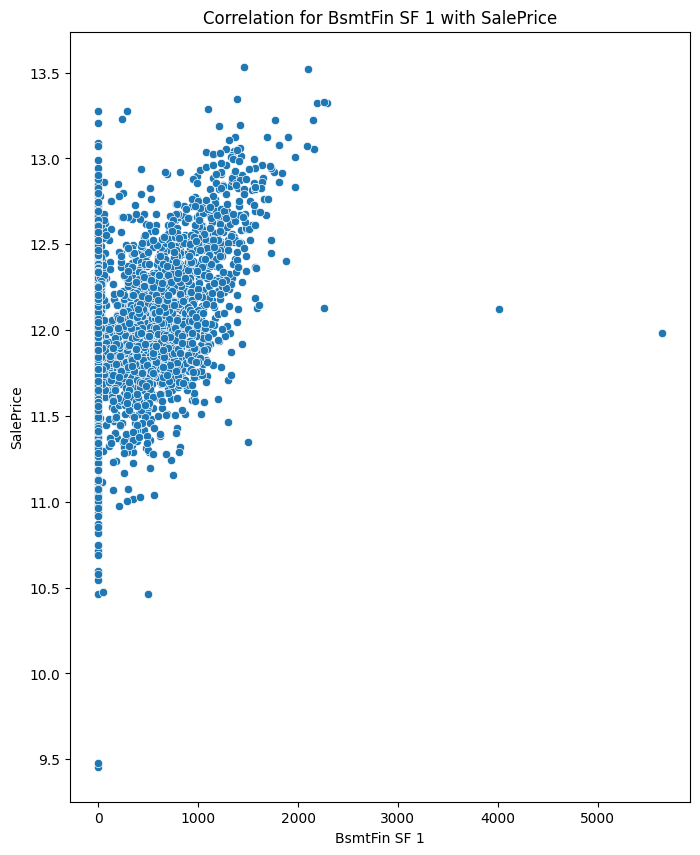

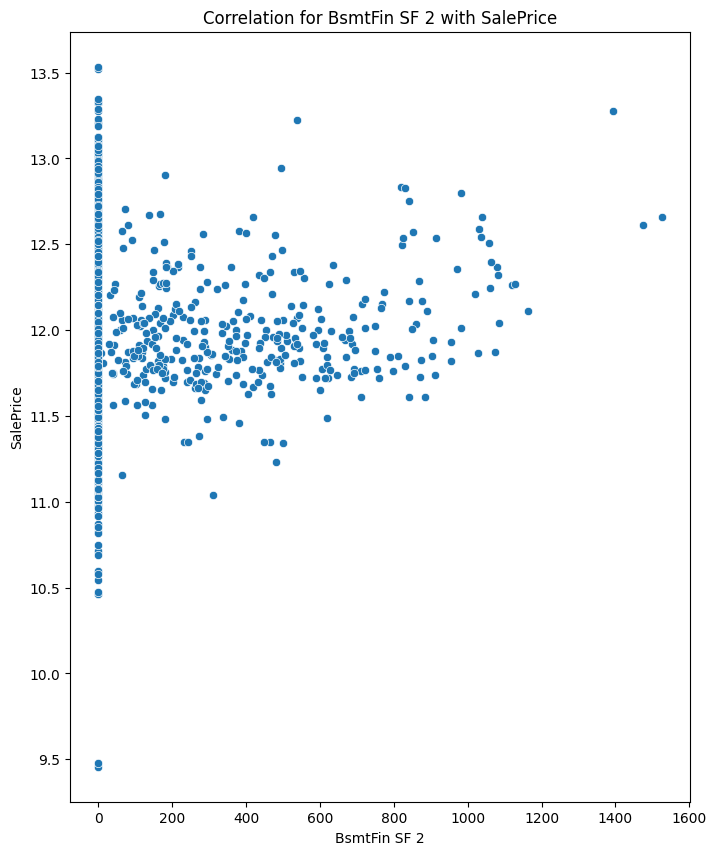

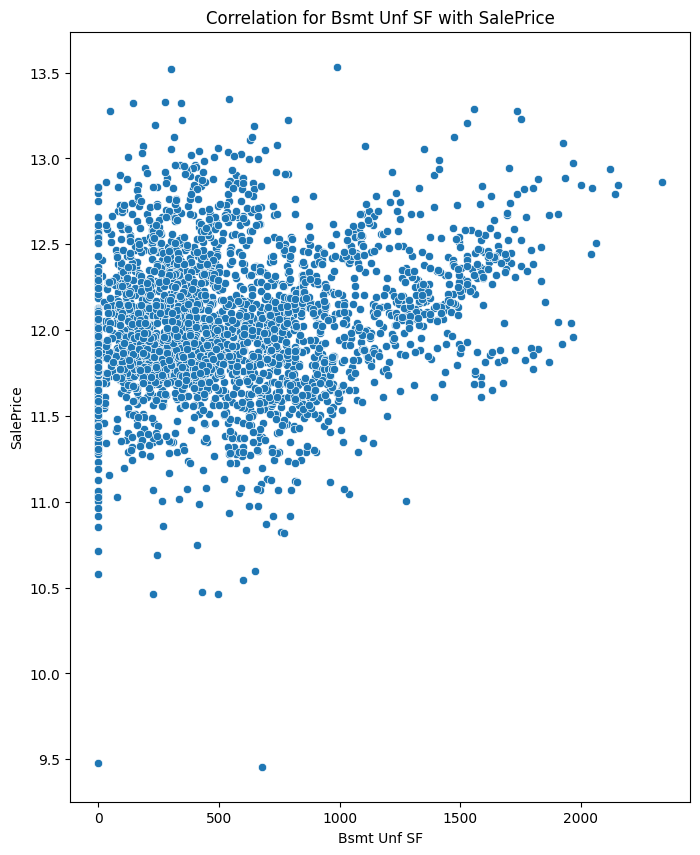

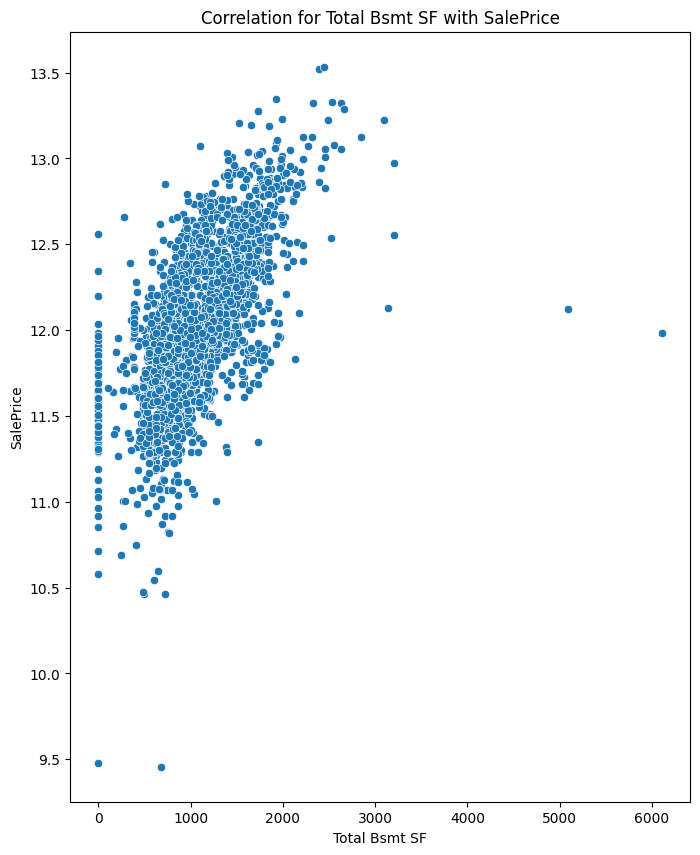

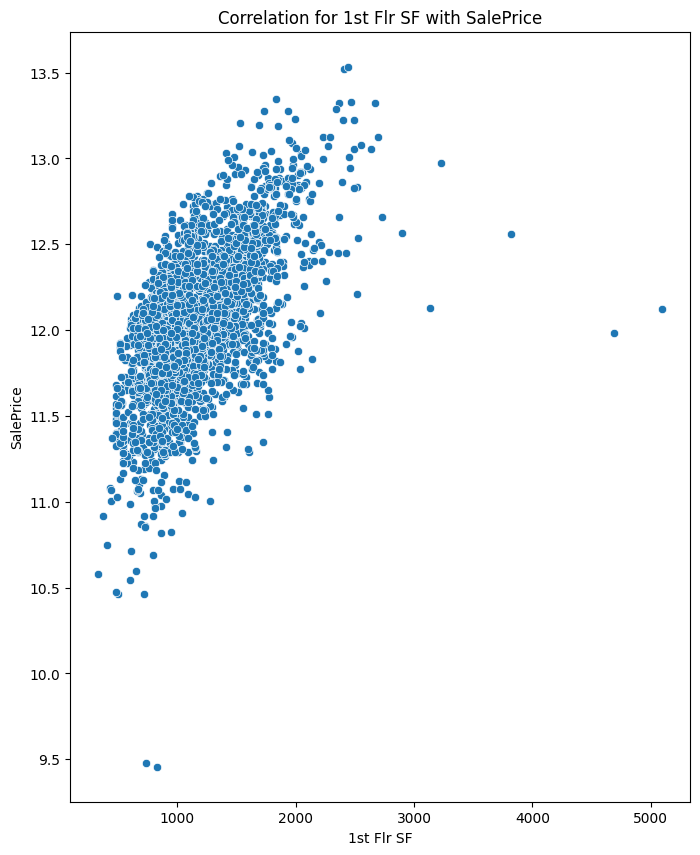

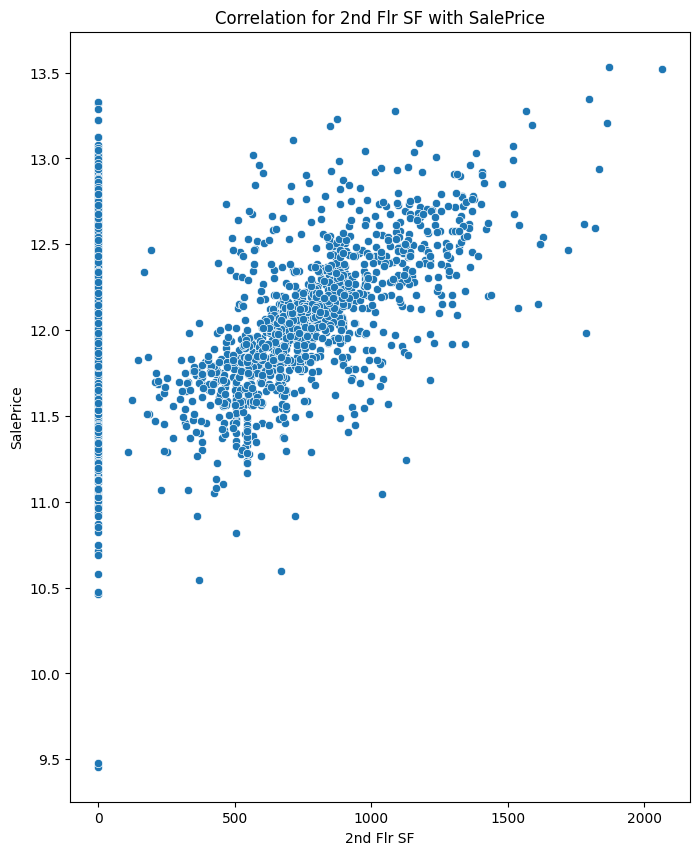

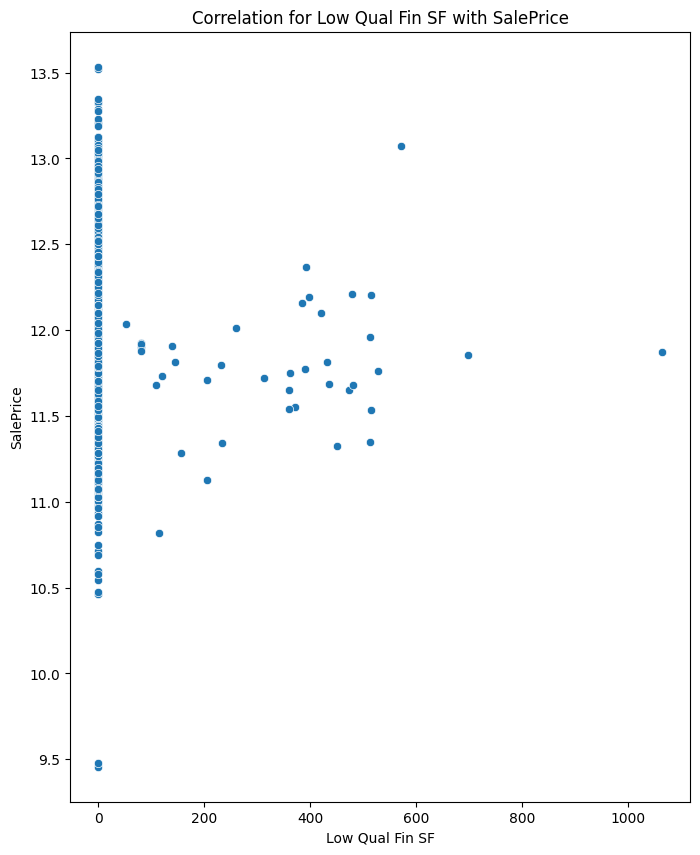

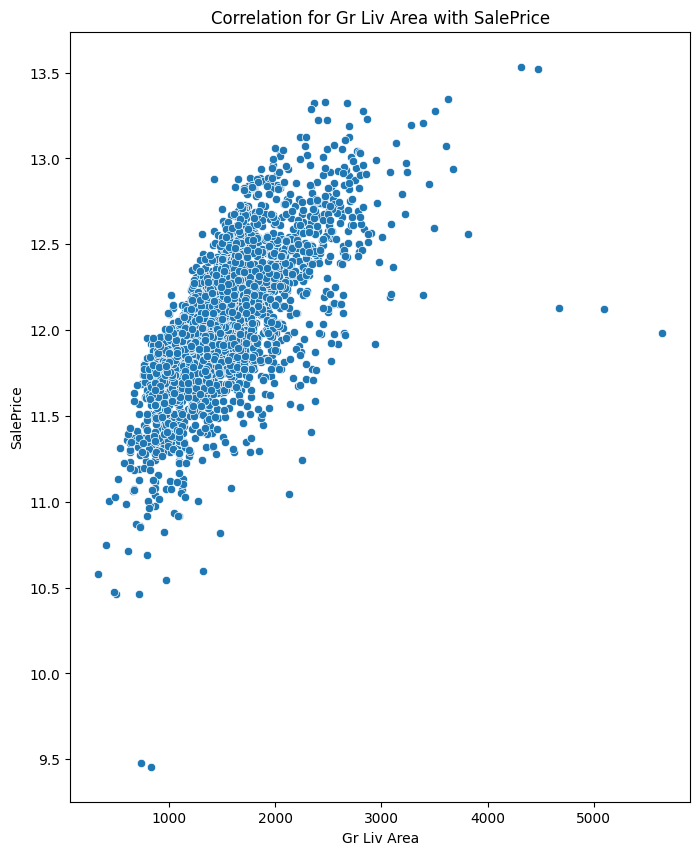

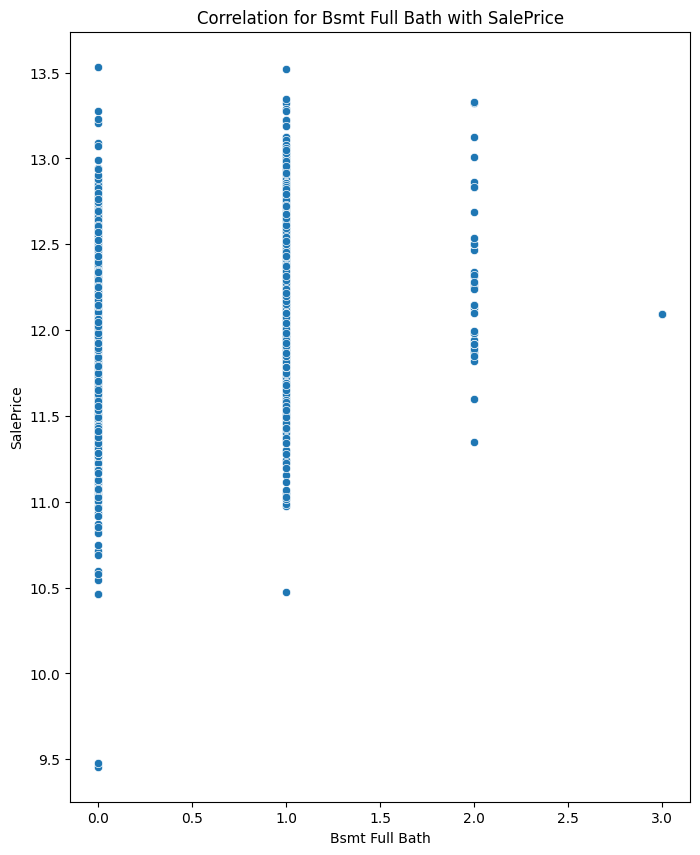

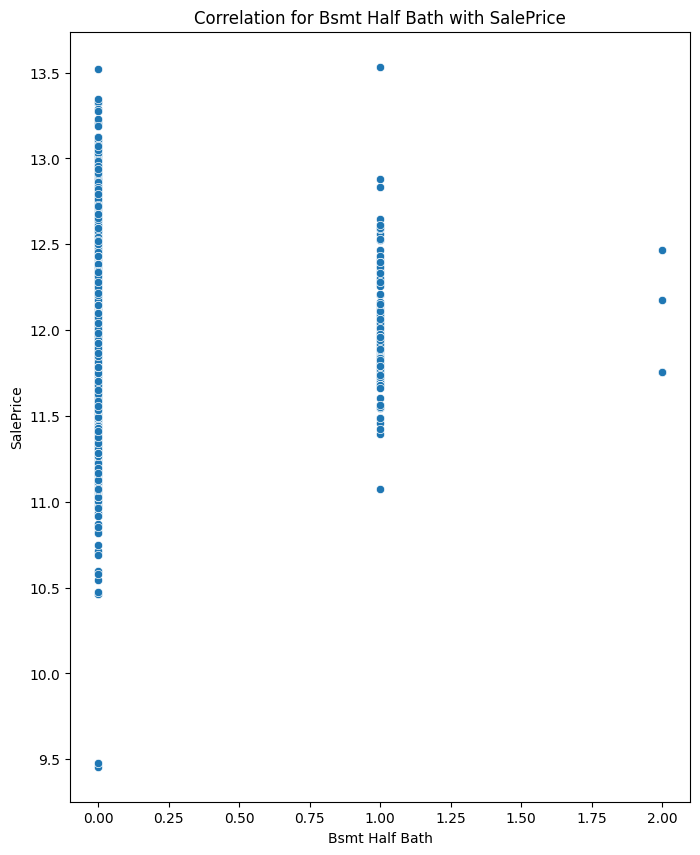

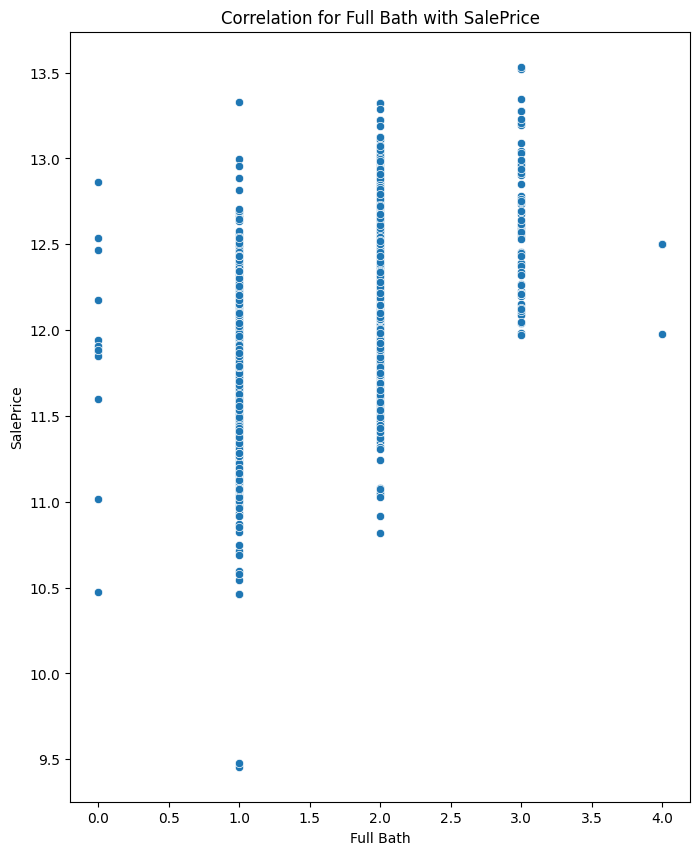

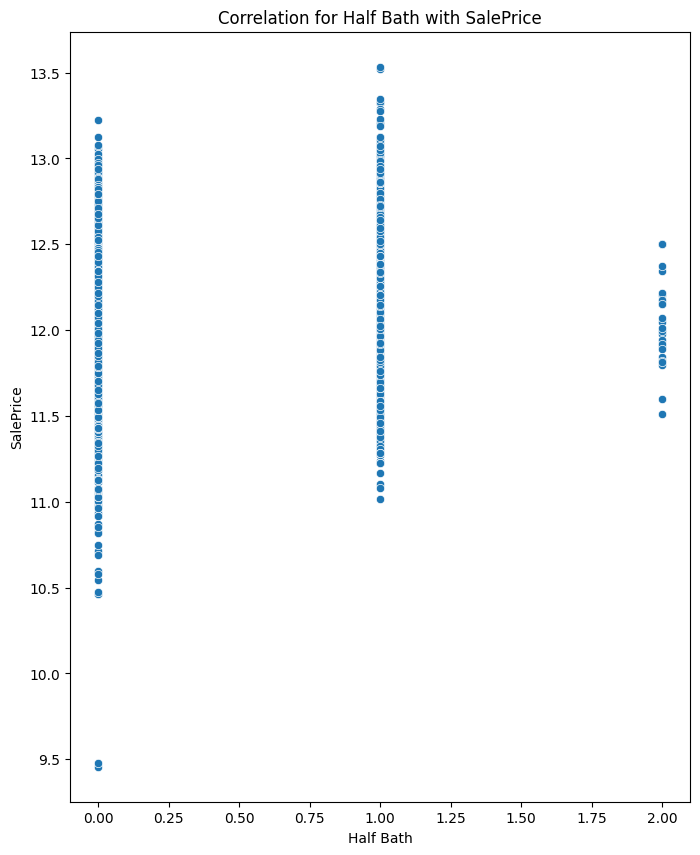

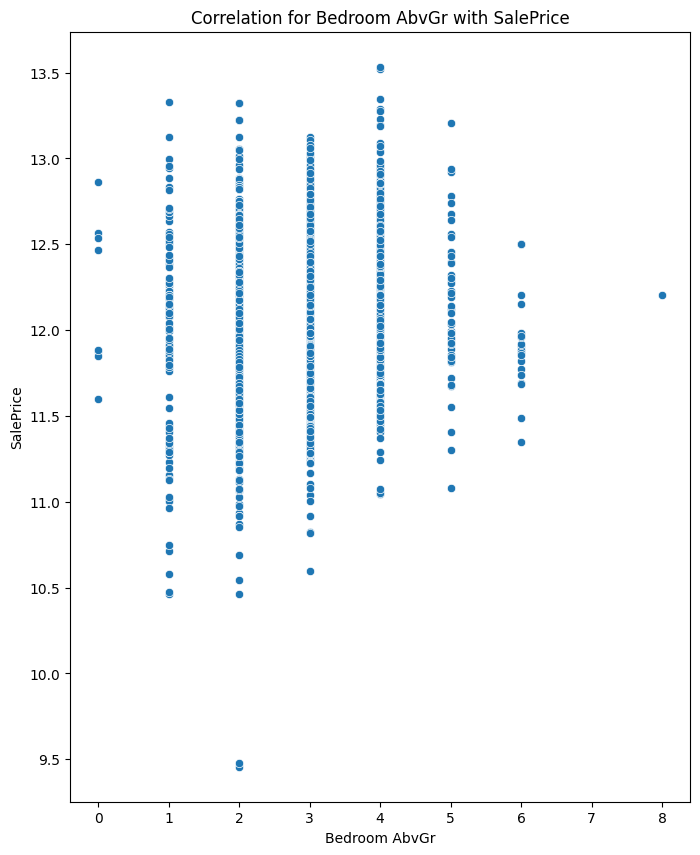

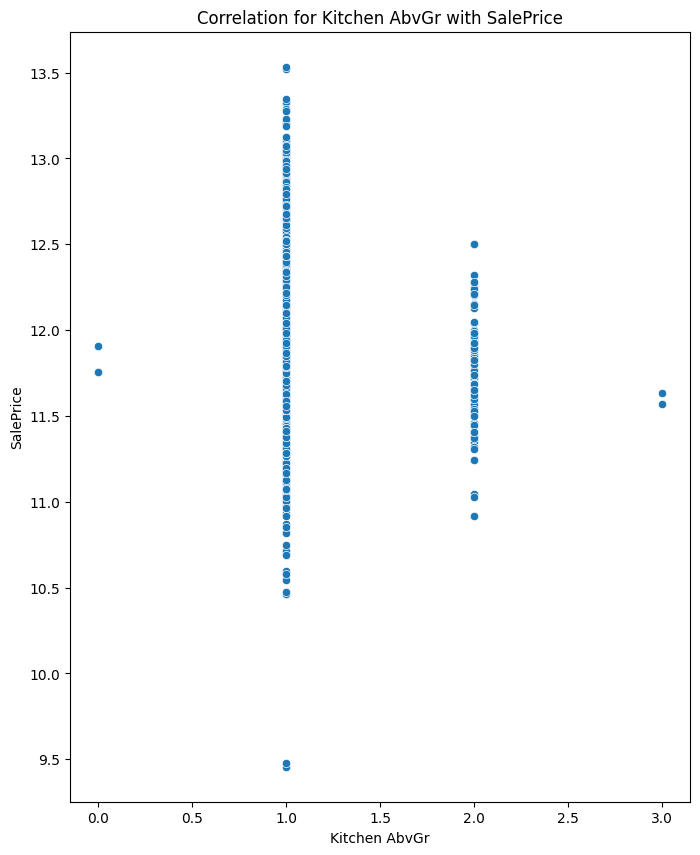

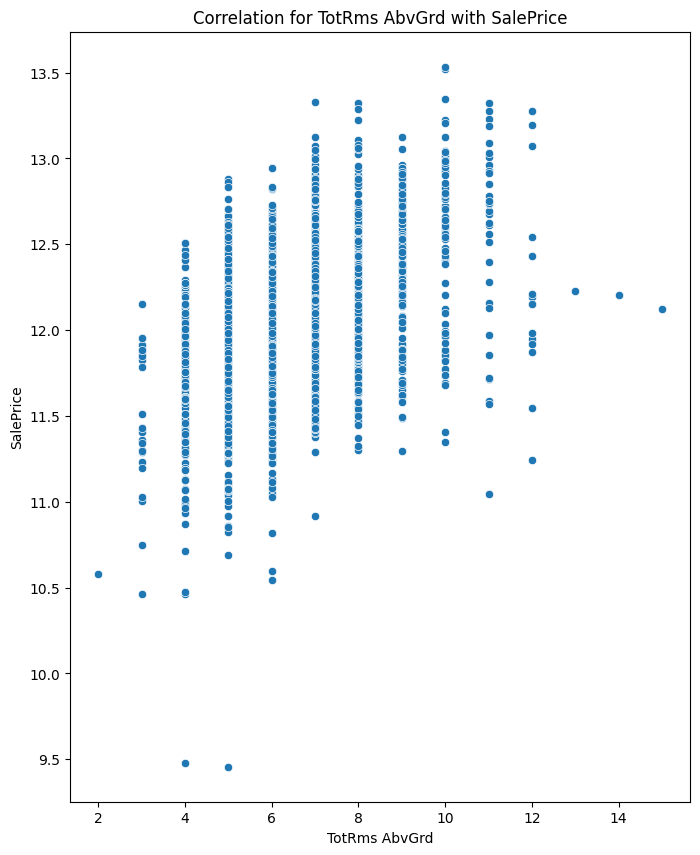

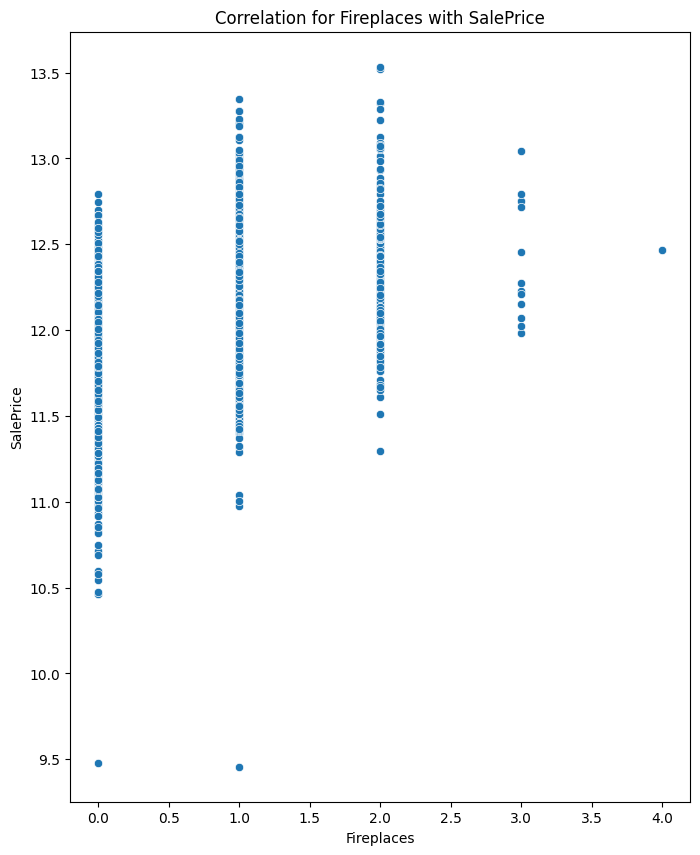

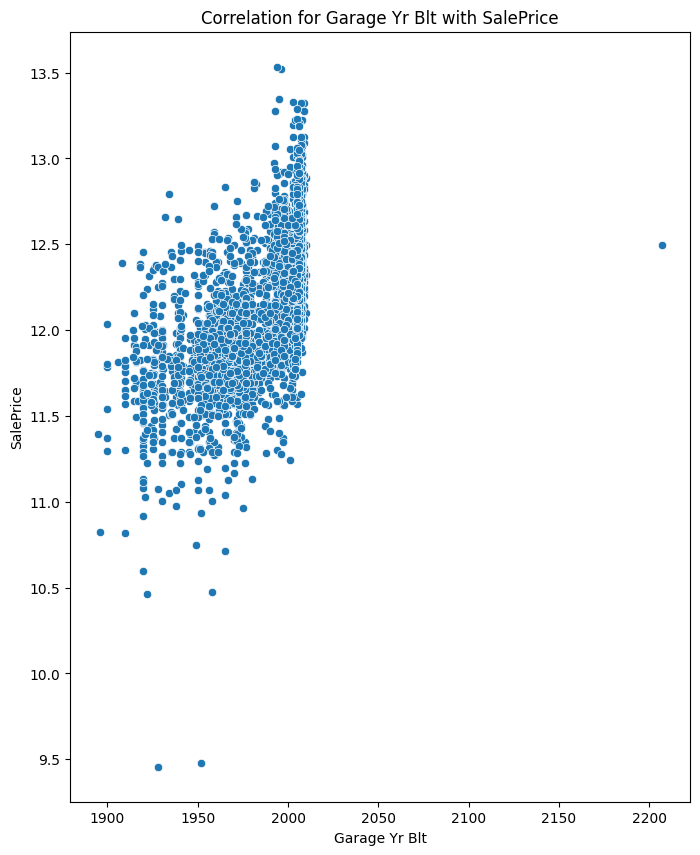

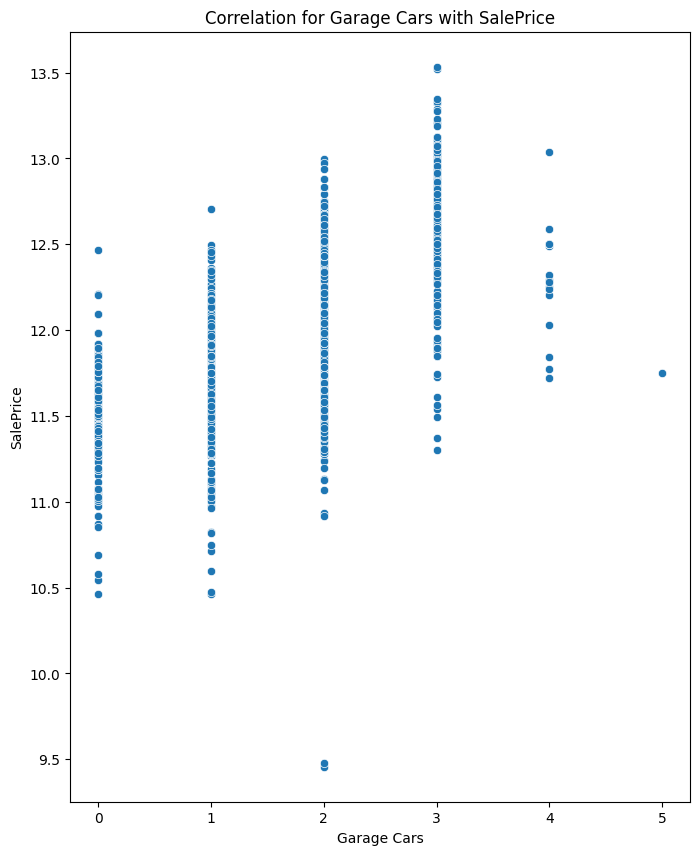

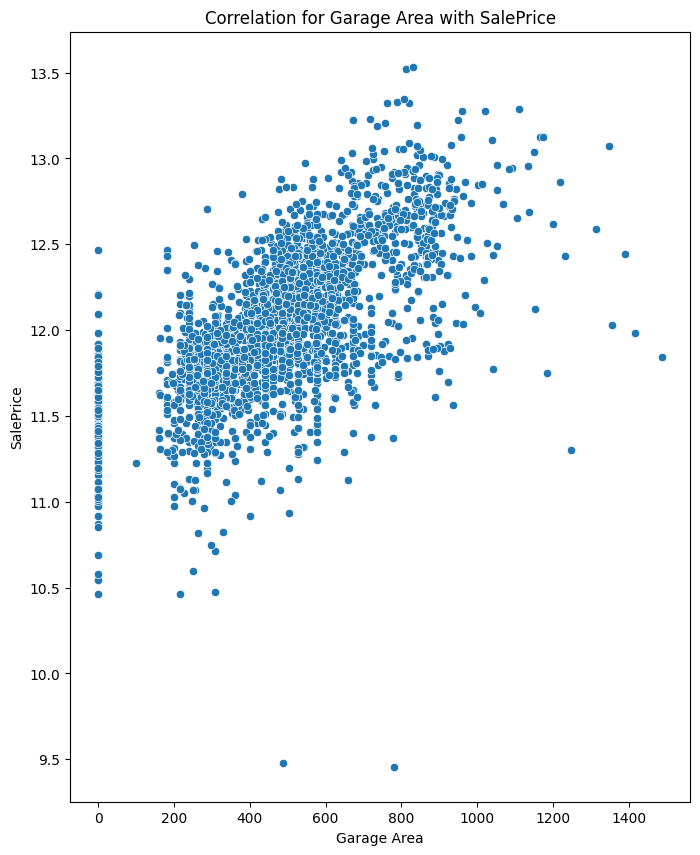

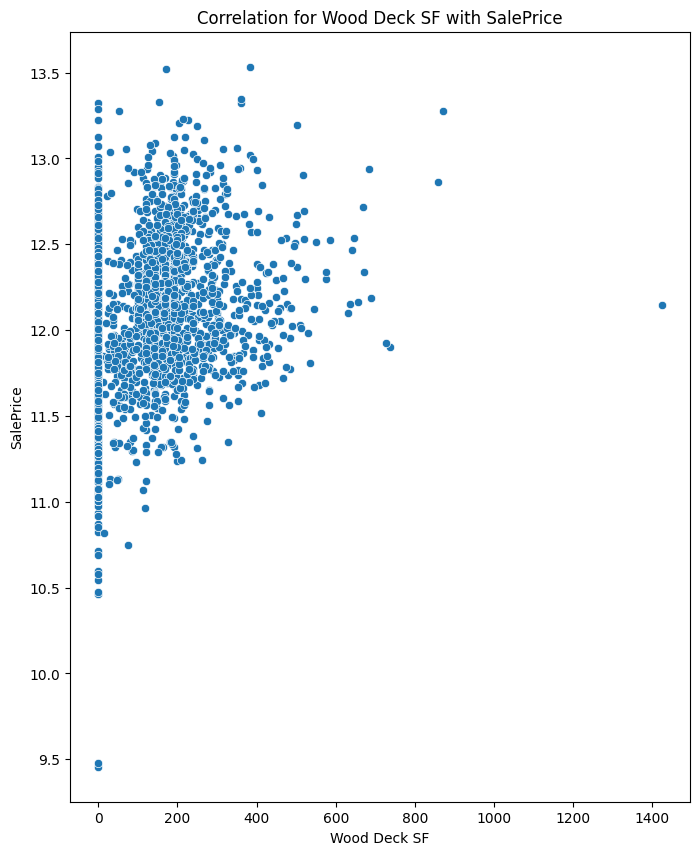

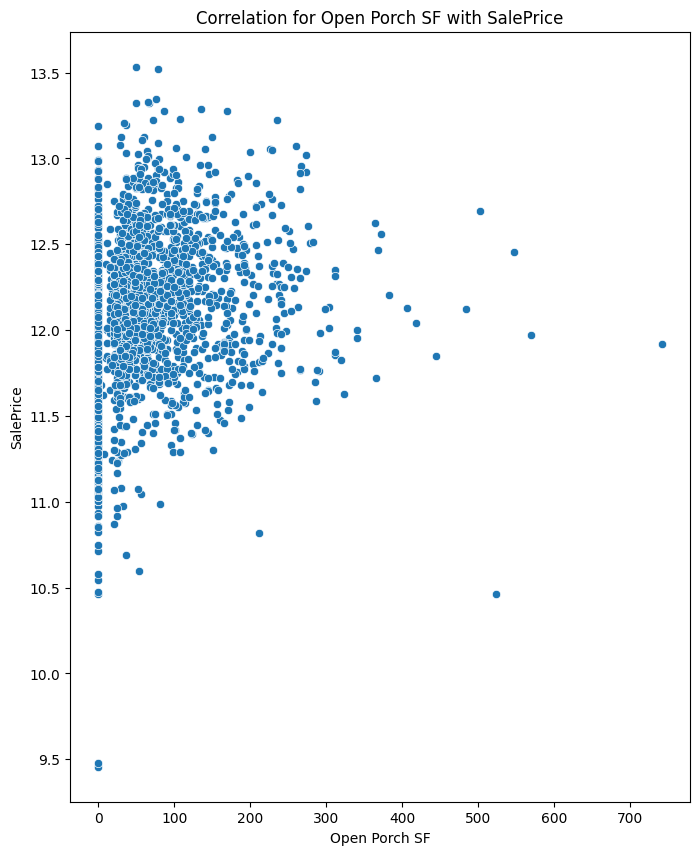

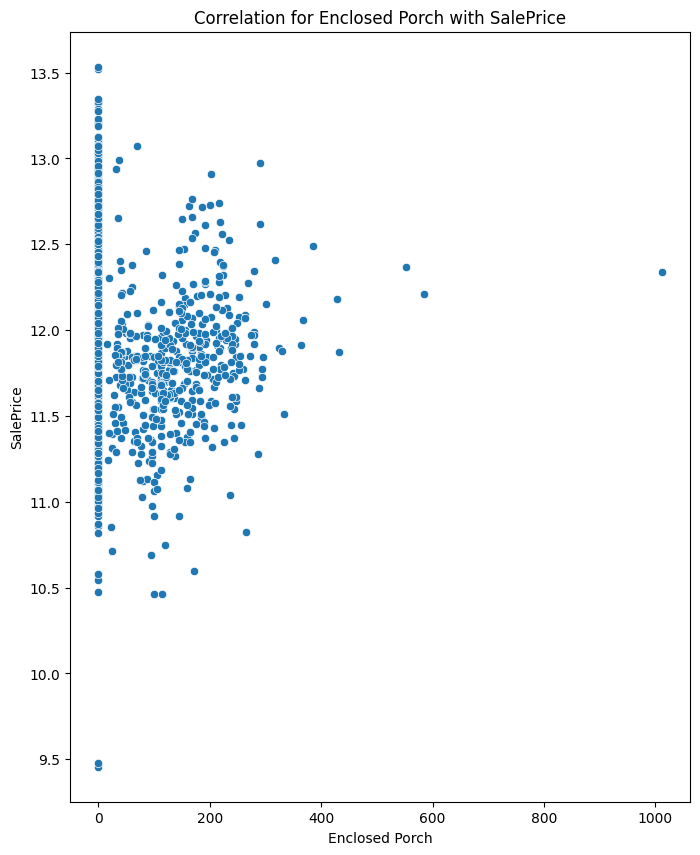

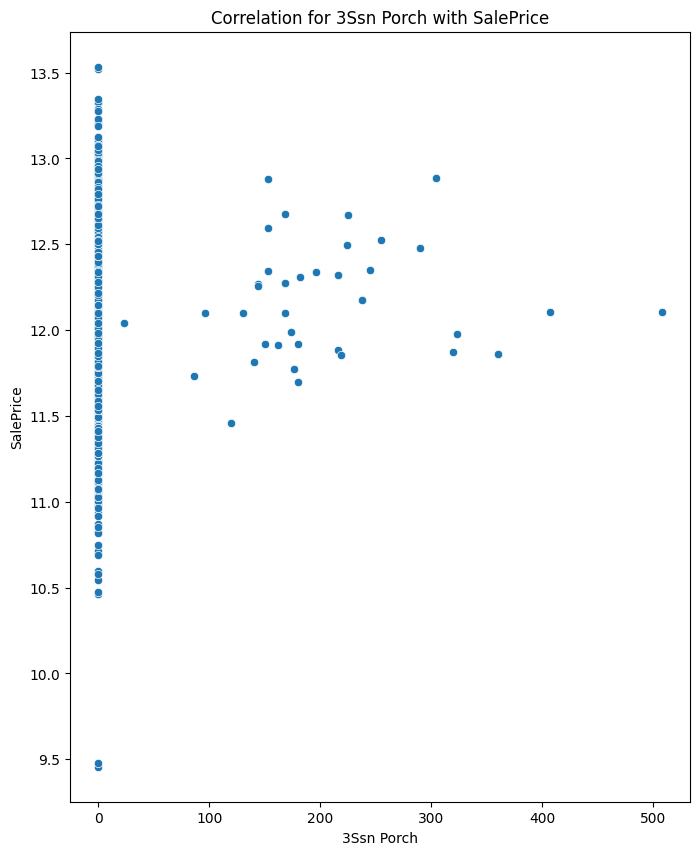

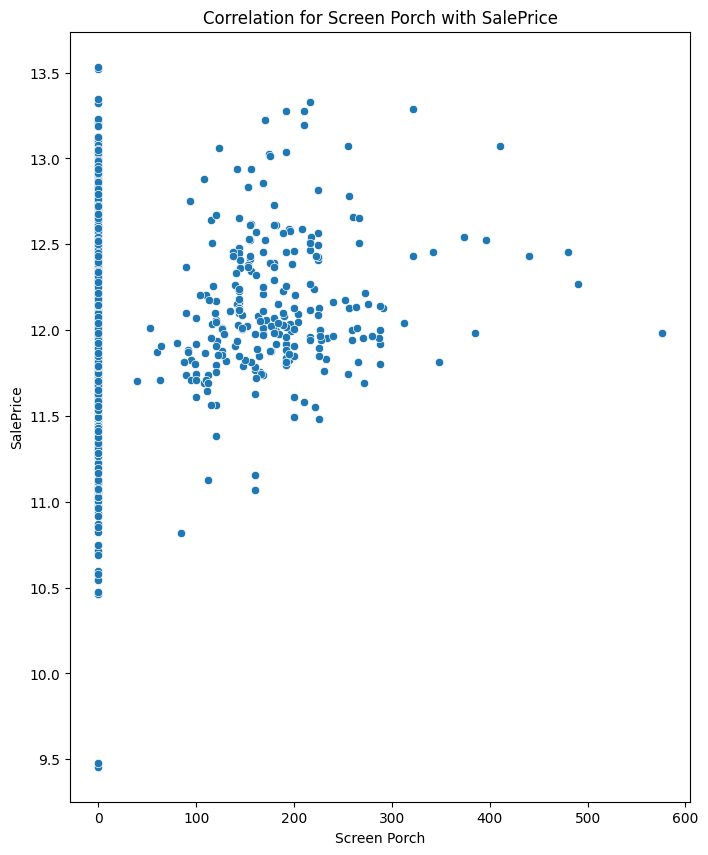

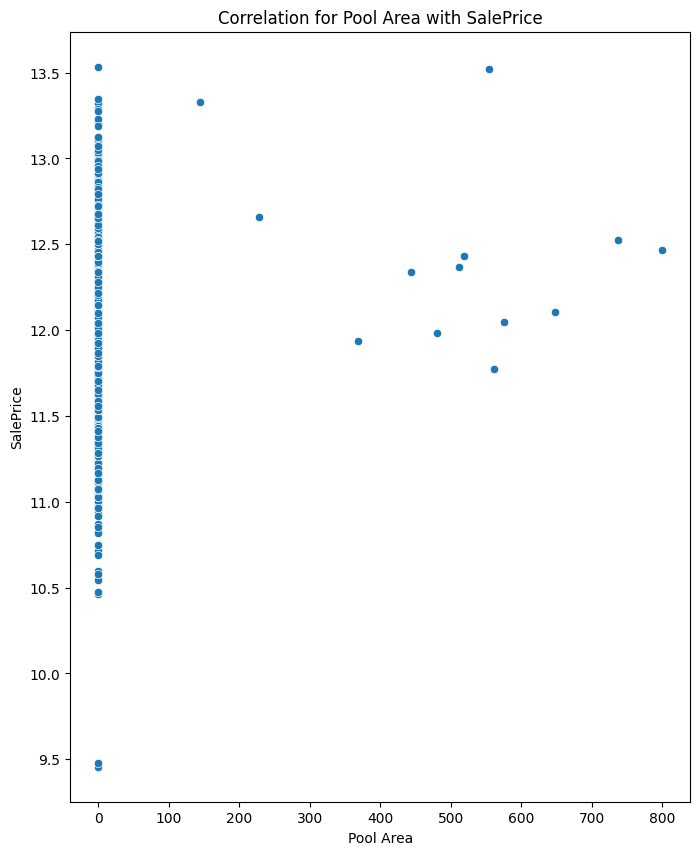

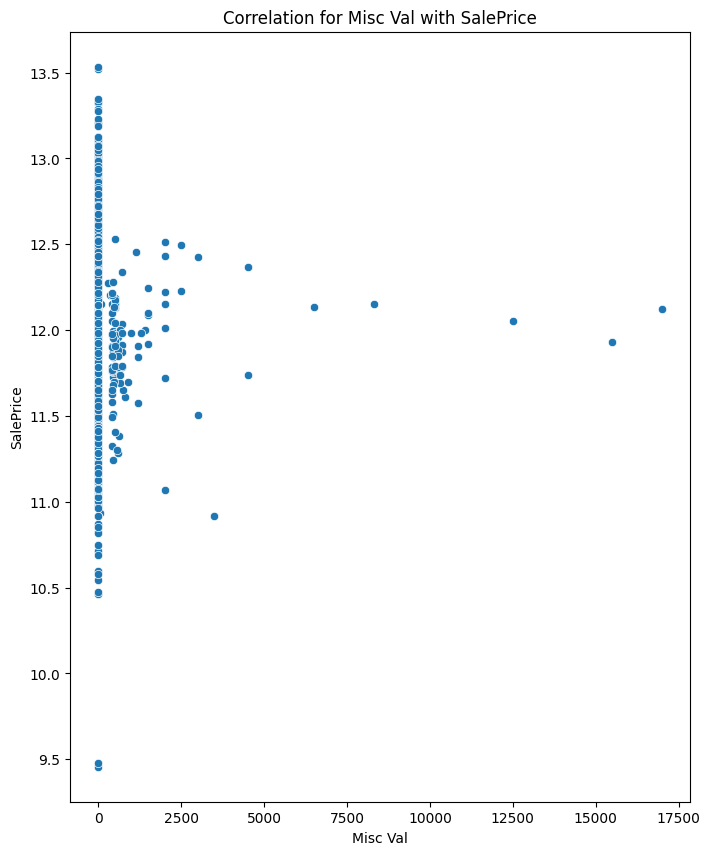

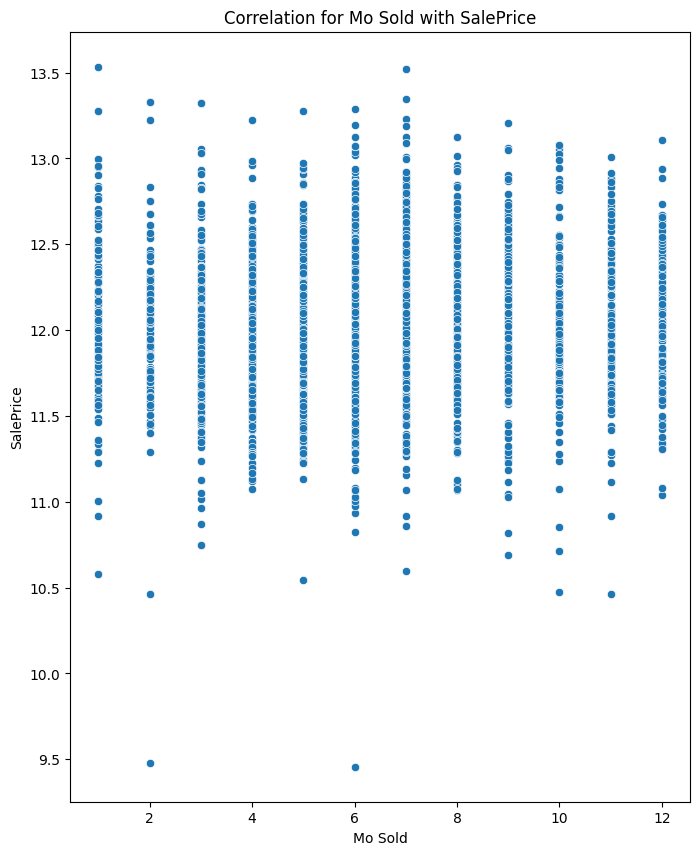

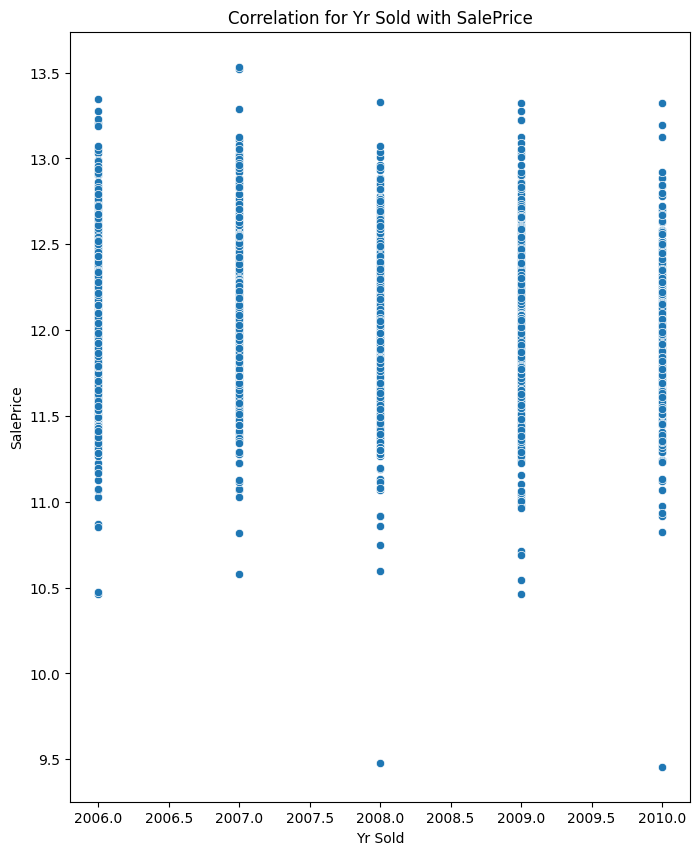

In [22]:
numerical_cols
for items in numerical_cols:
    plt.figure(figsize=(8,10))
    sns.scatterplot(data, x=items, y="SalePrice")
    plt.title(f"Correlation for {items} with SalePrice")
    plt.ylabel("SalePrice")
    plt.xlabel(items)
    plt.show()

### BOXPLOT FOR CATEGORICAL VARIABLES

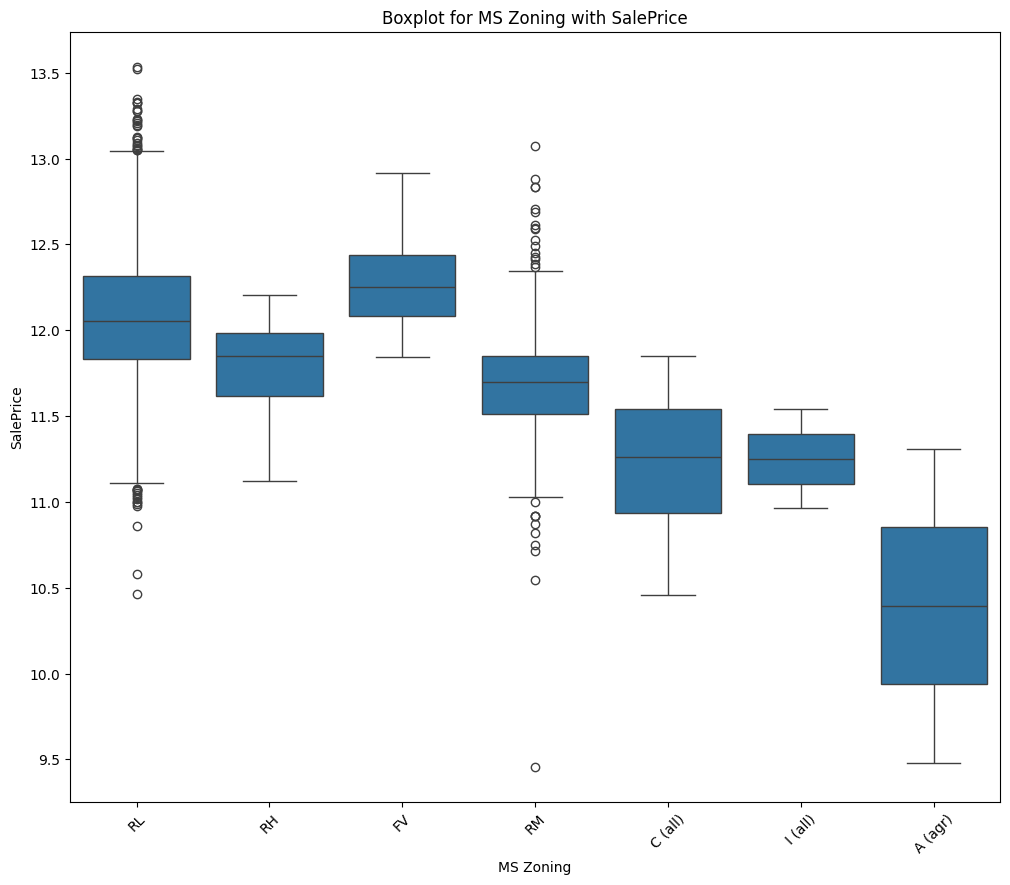

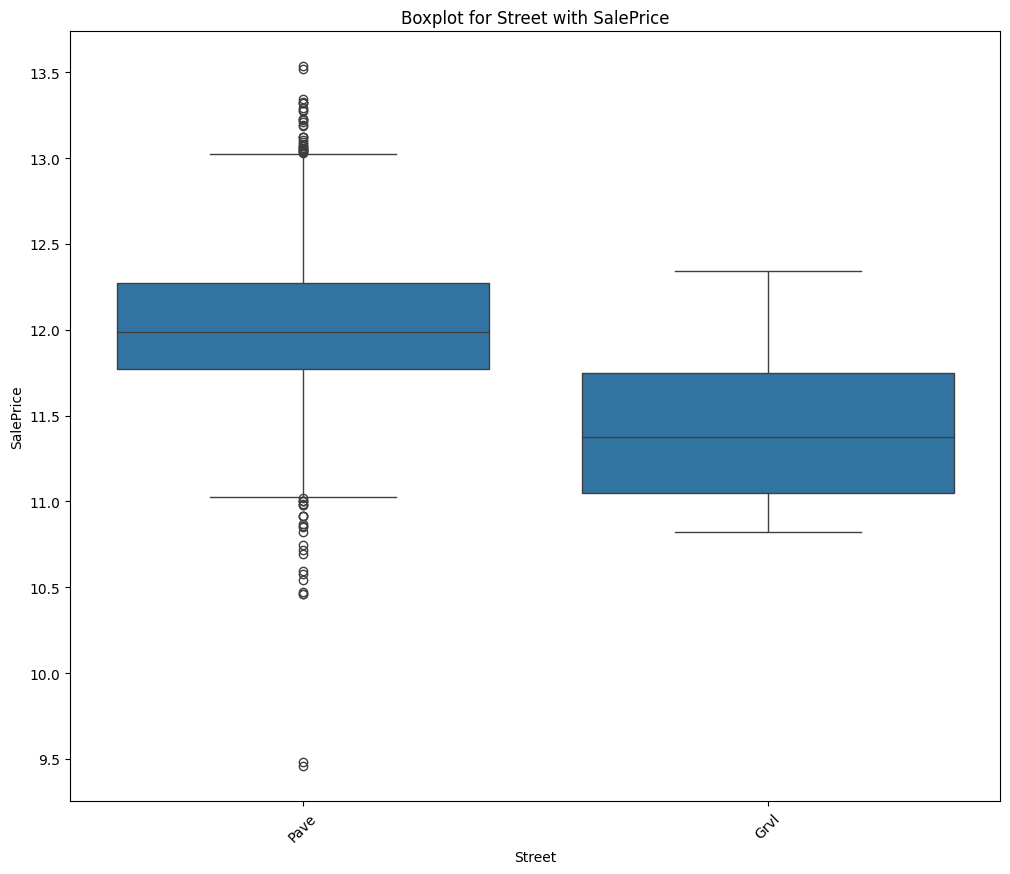

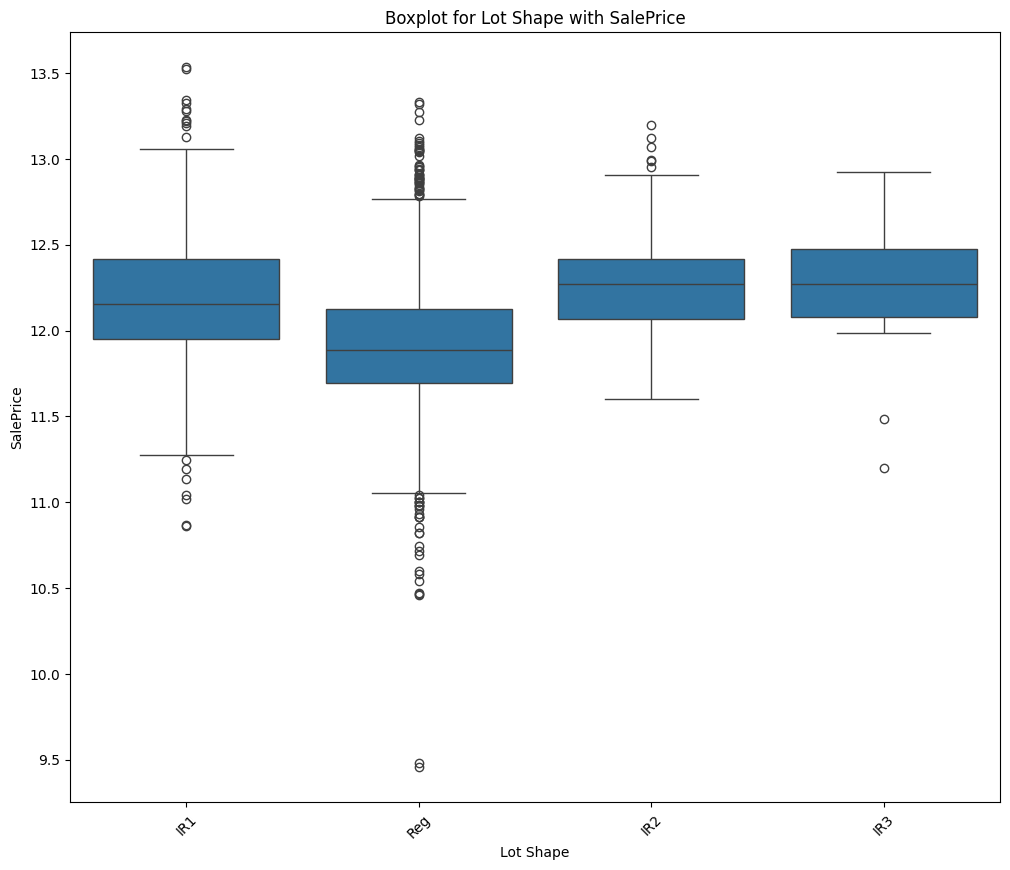

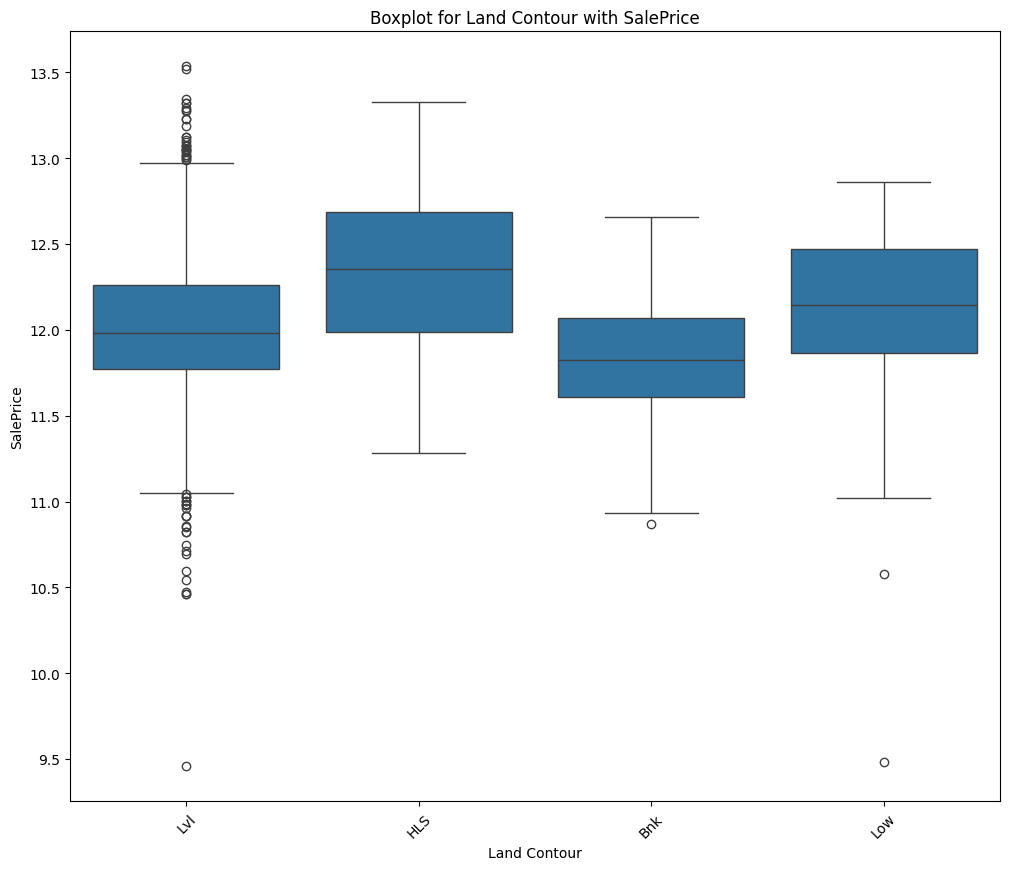

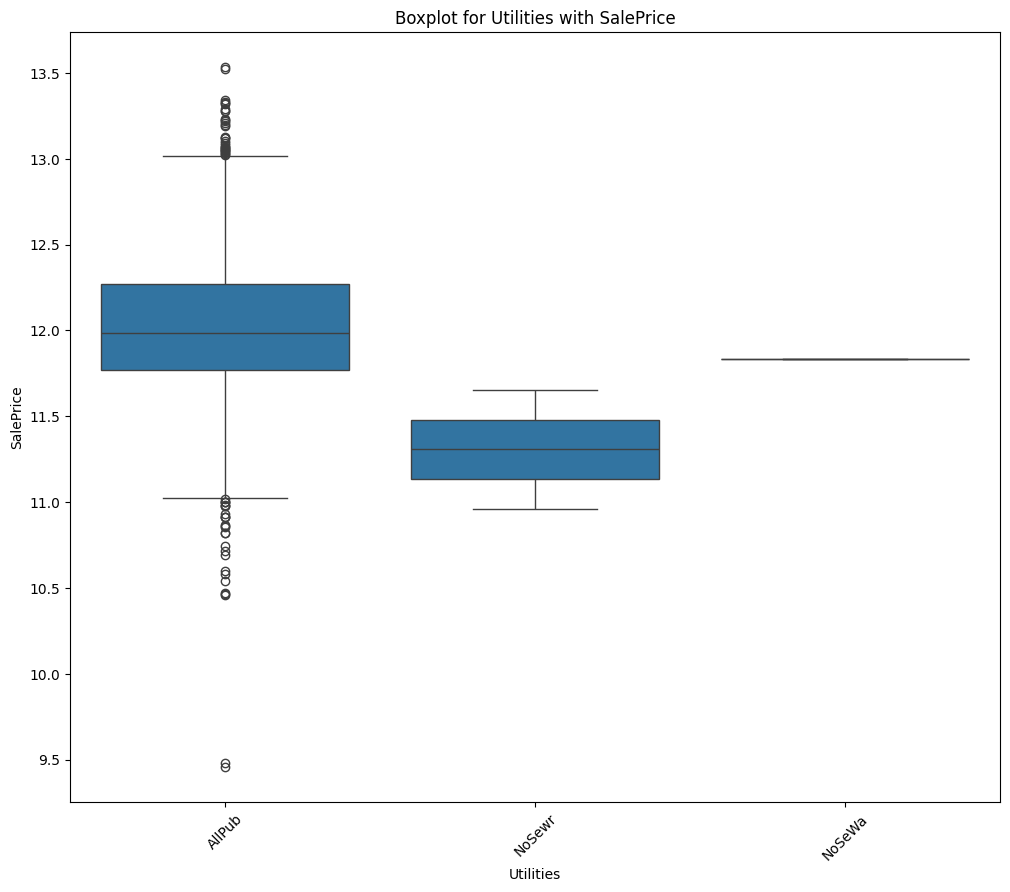

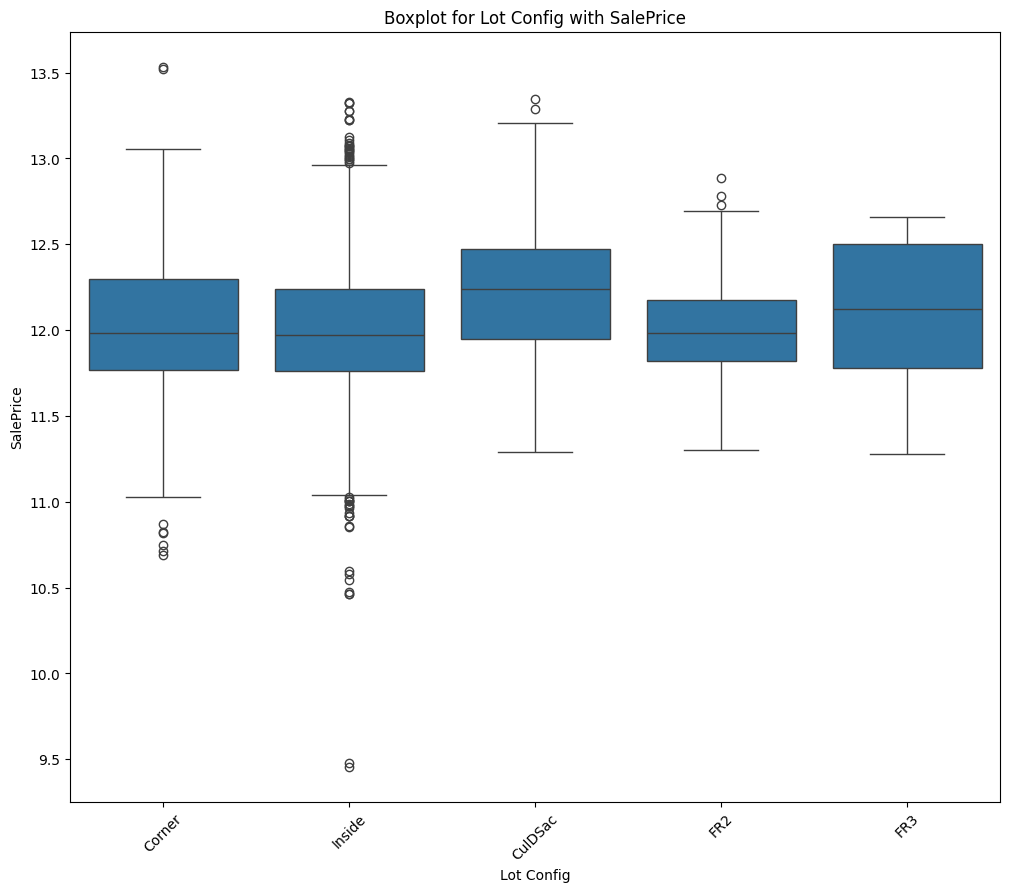

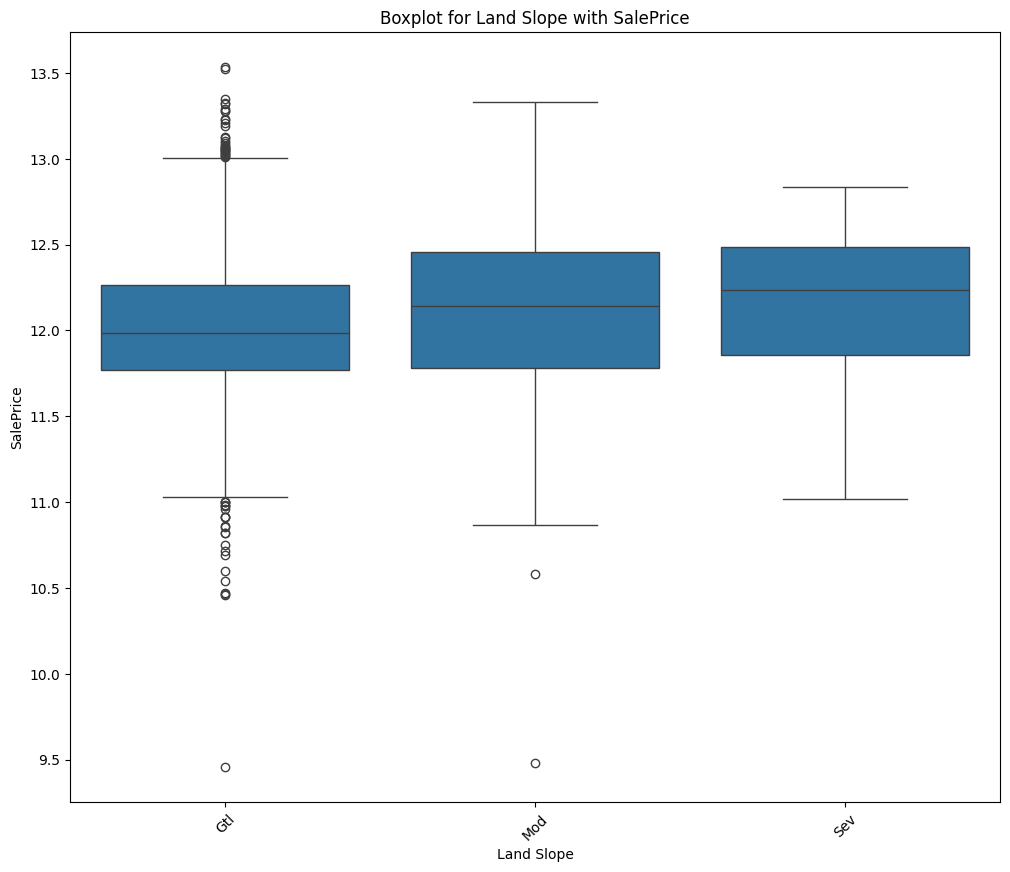

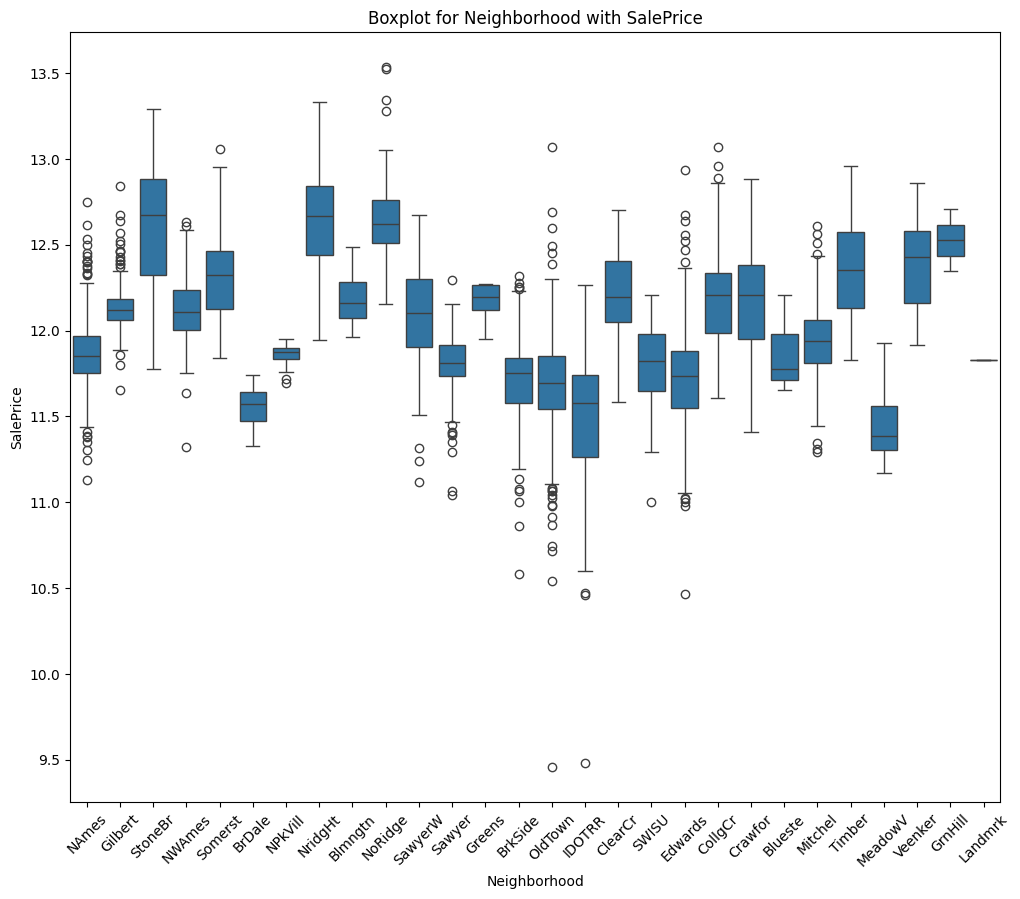

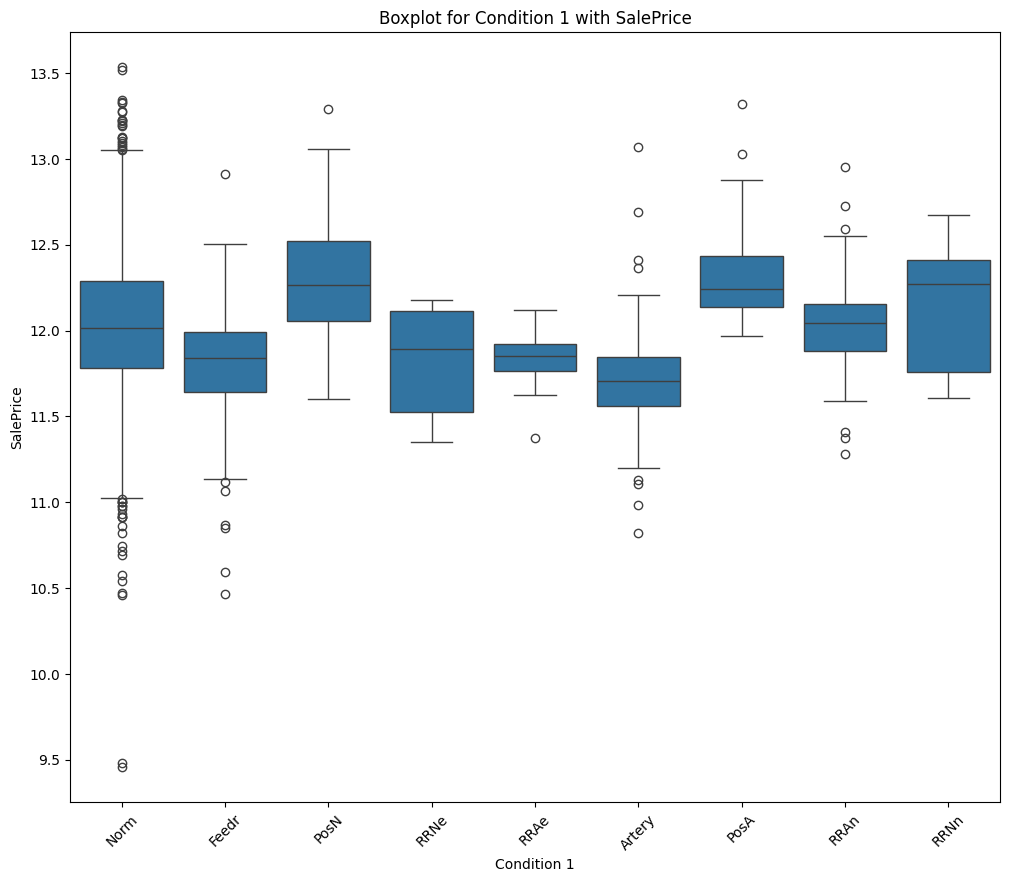

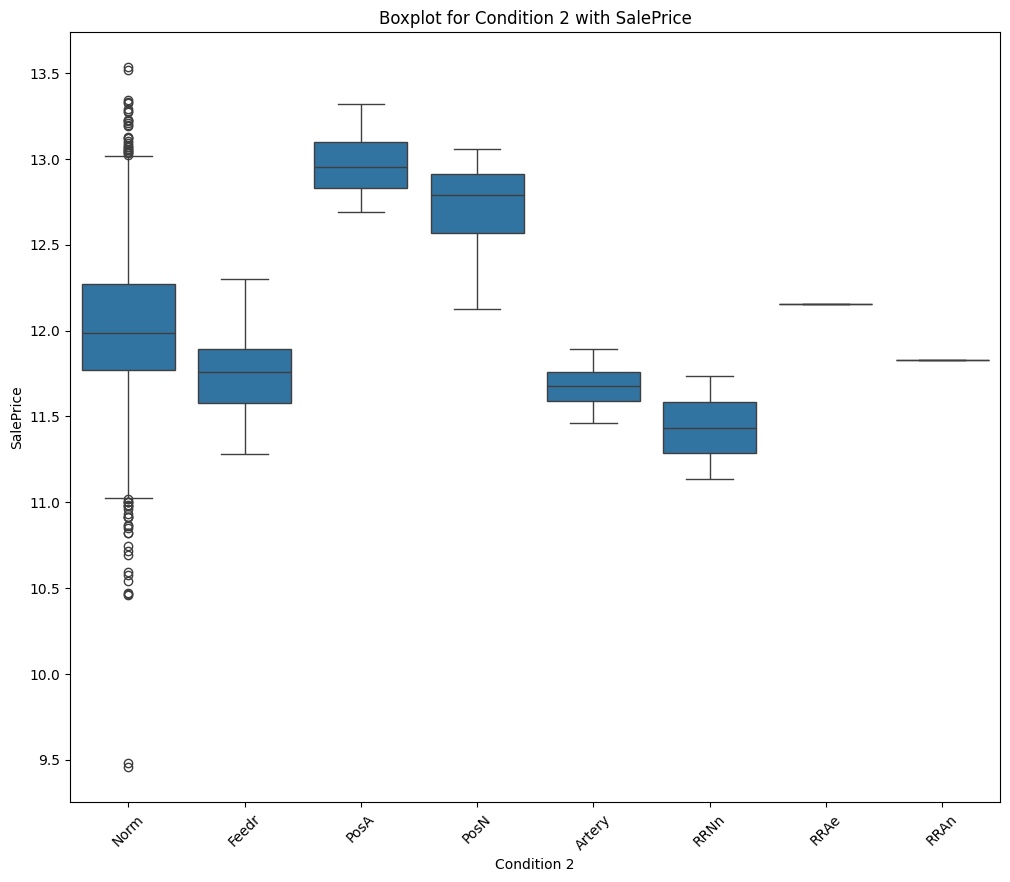

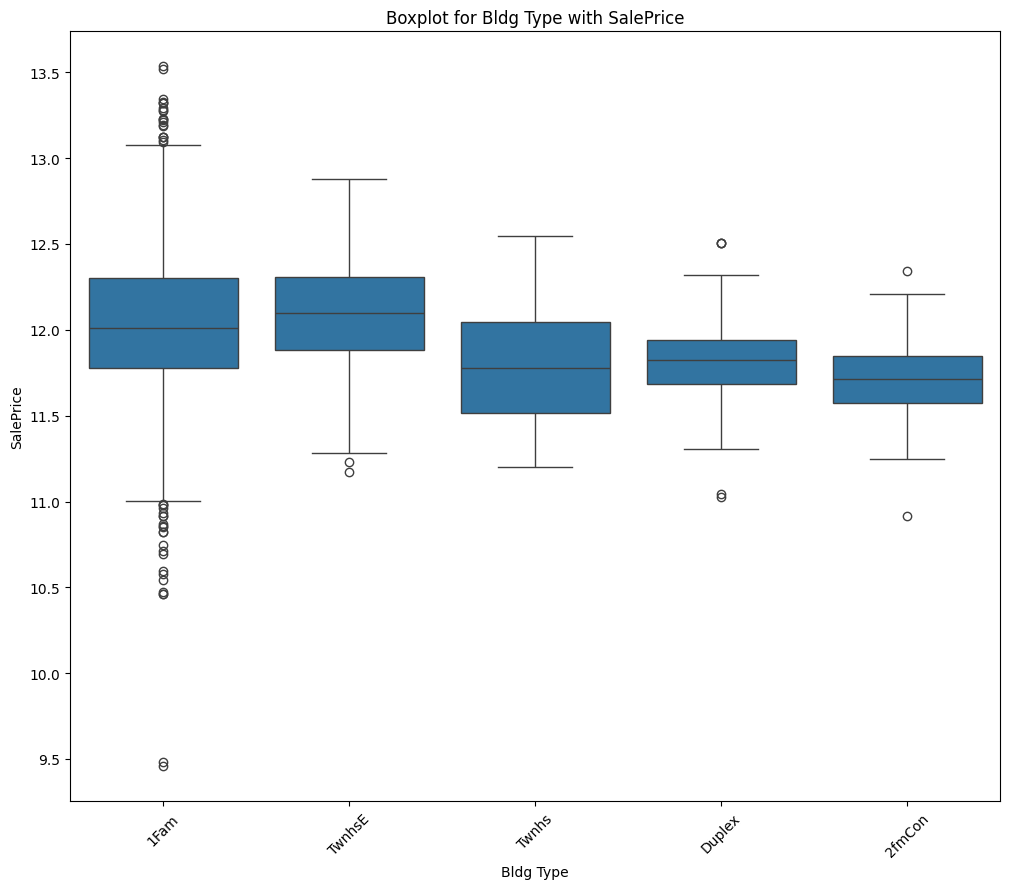

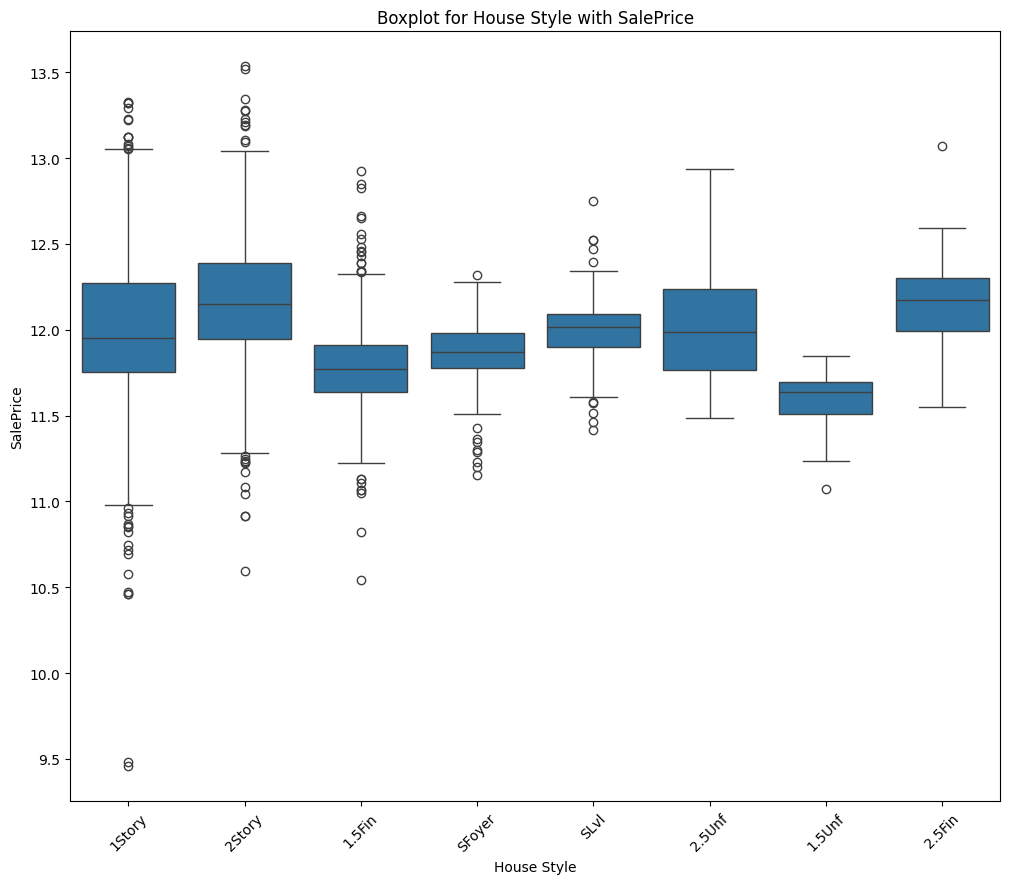

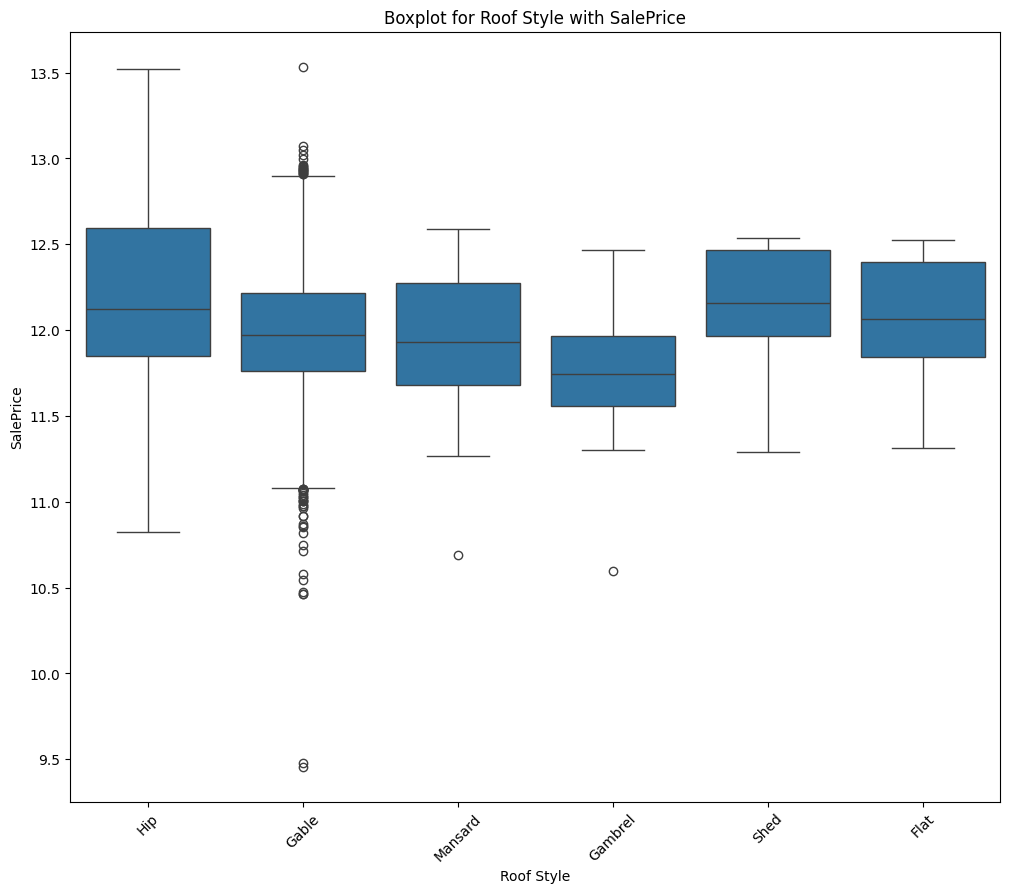

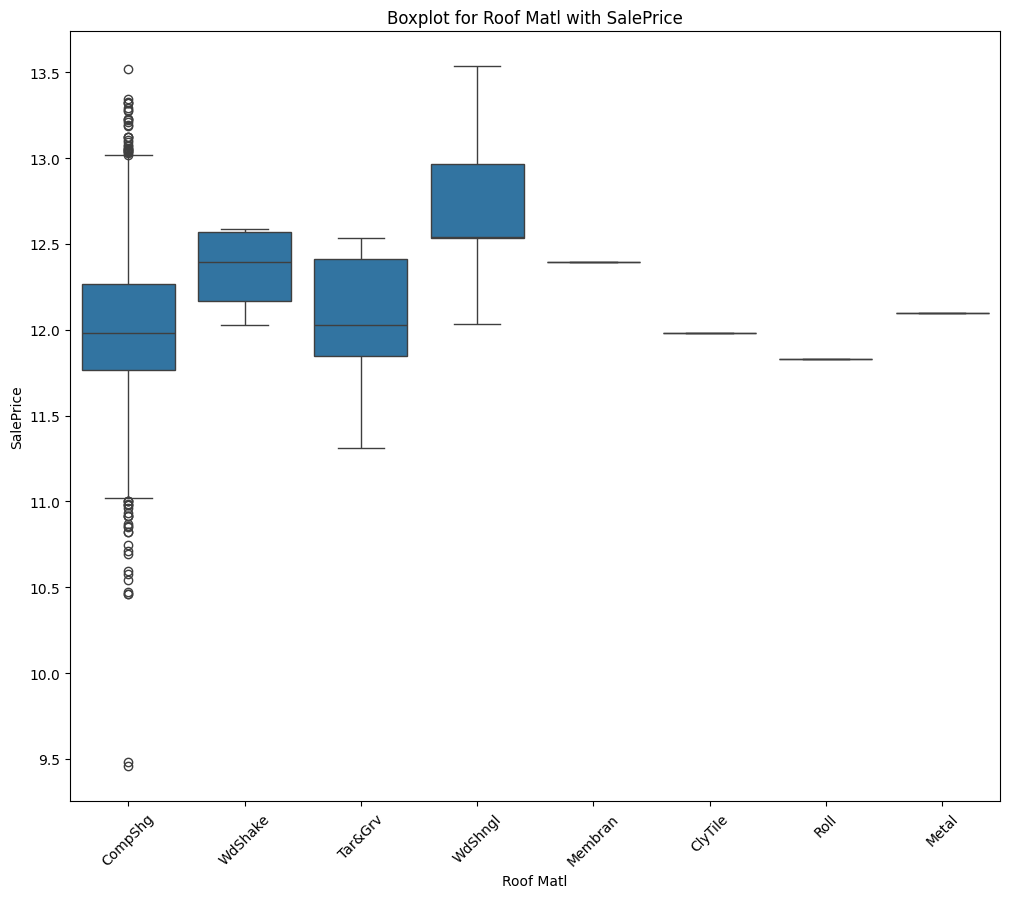

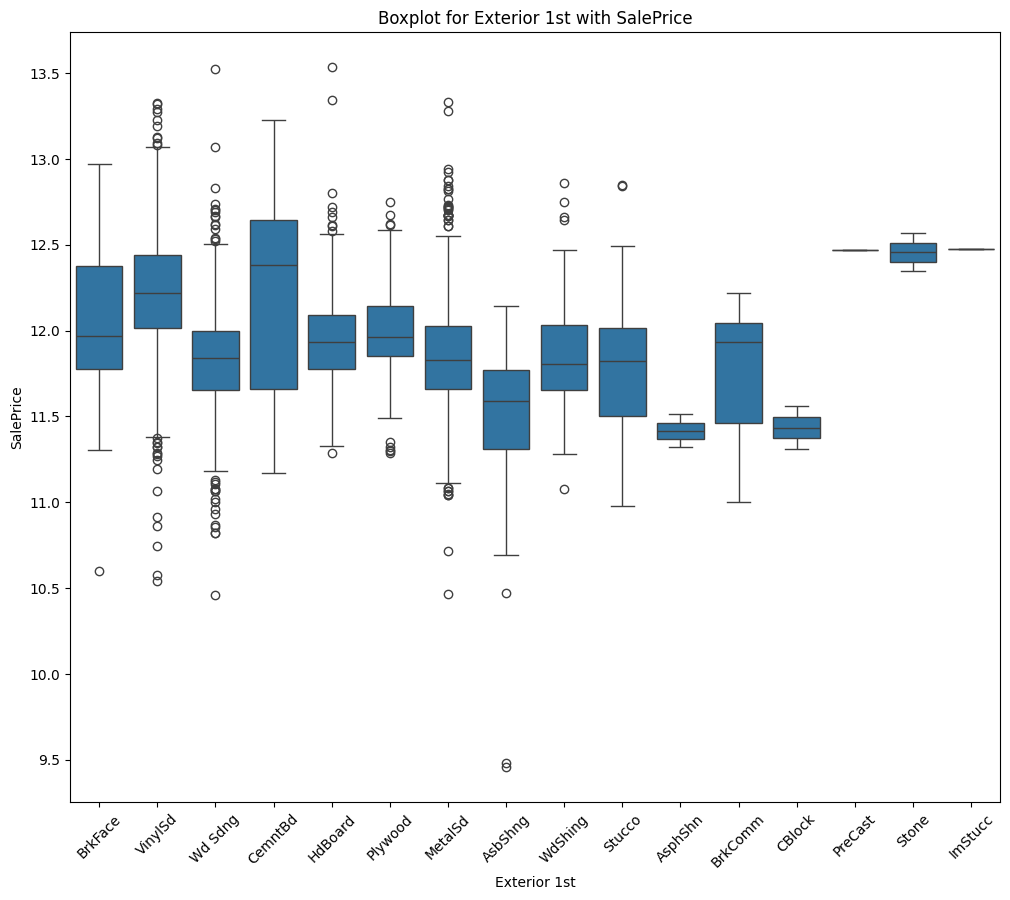

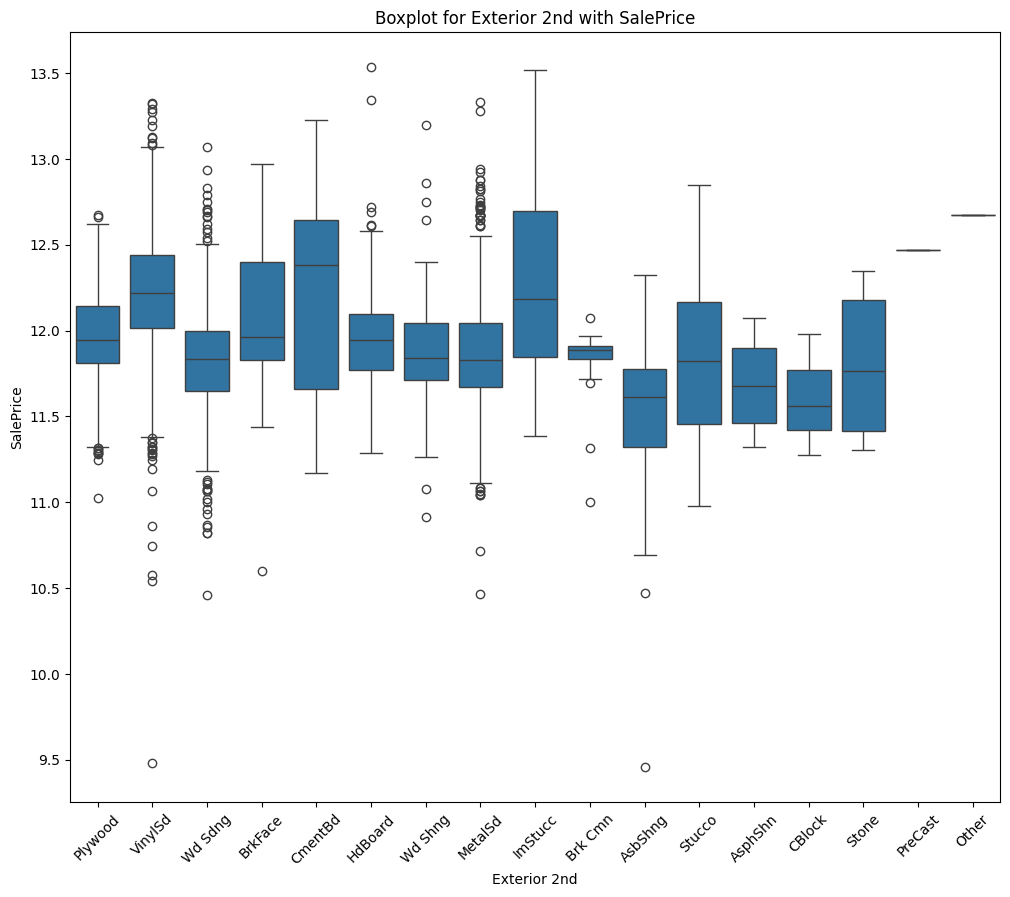

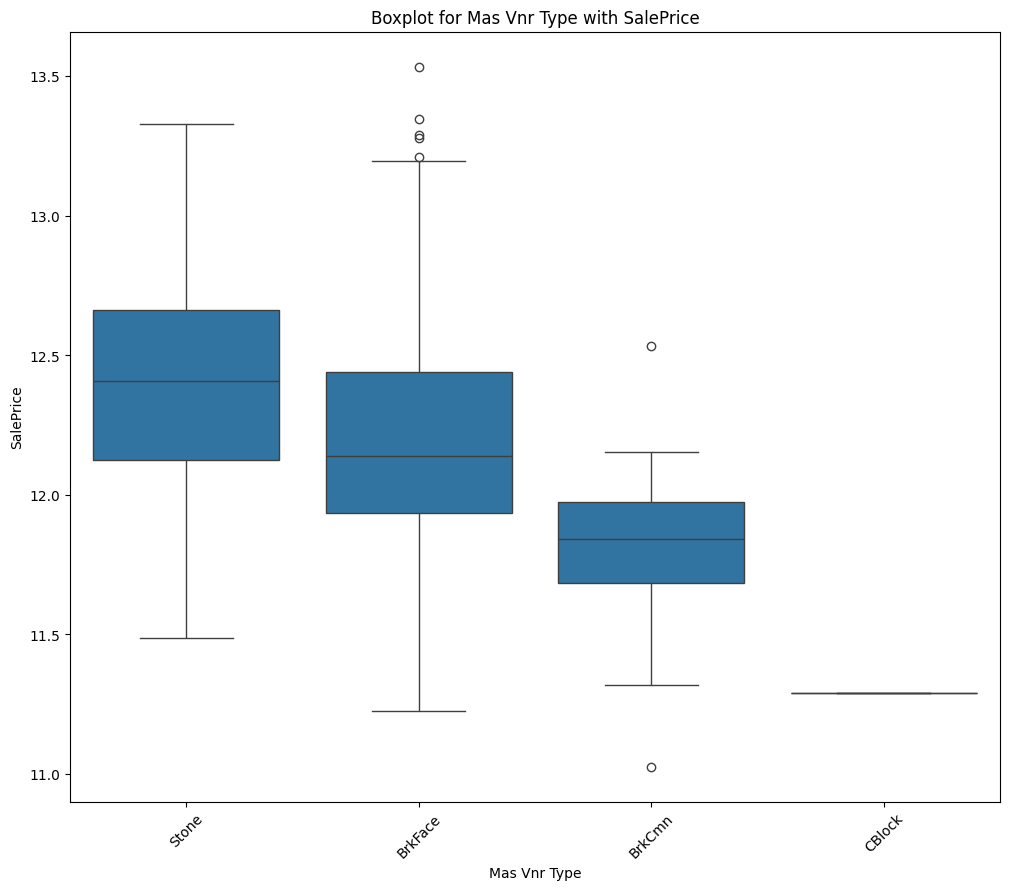

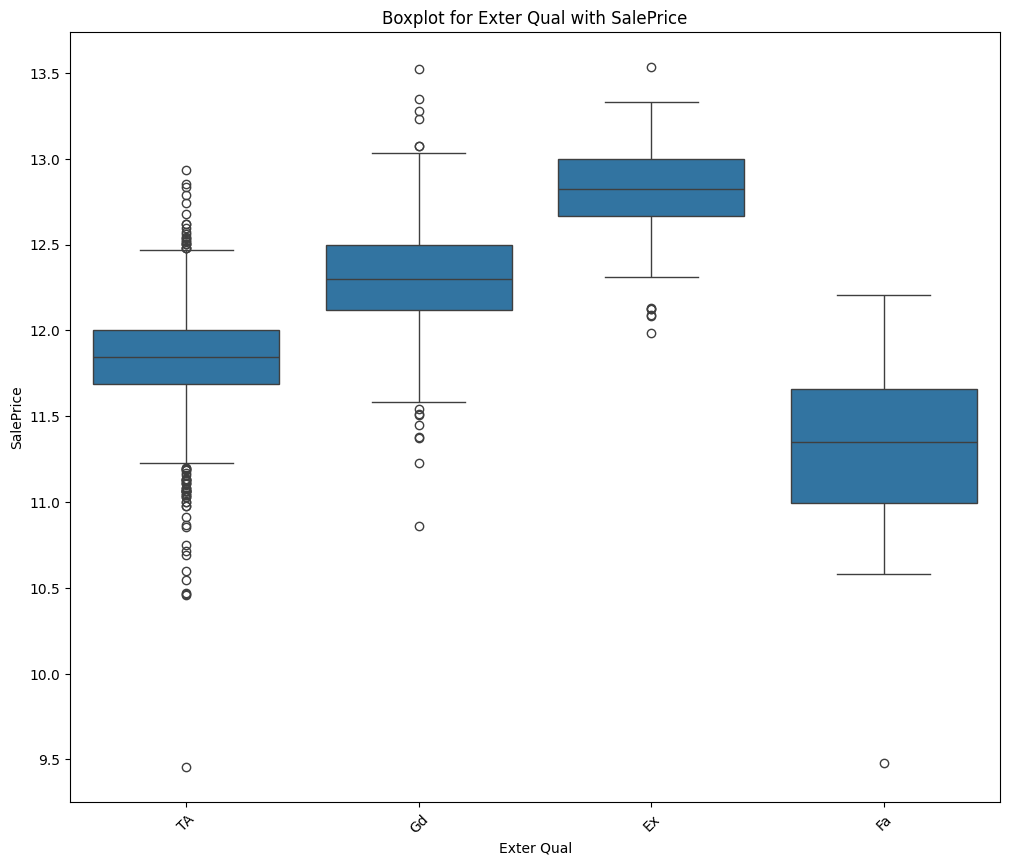

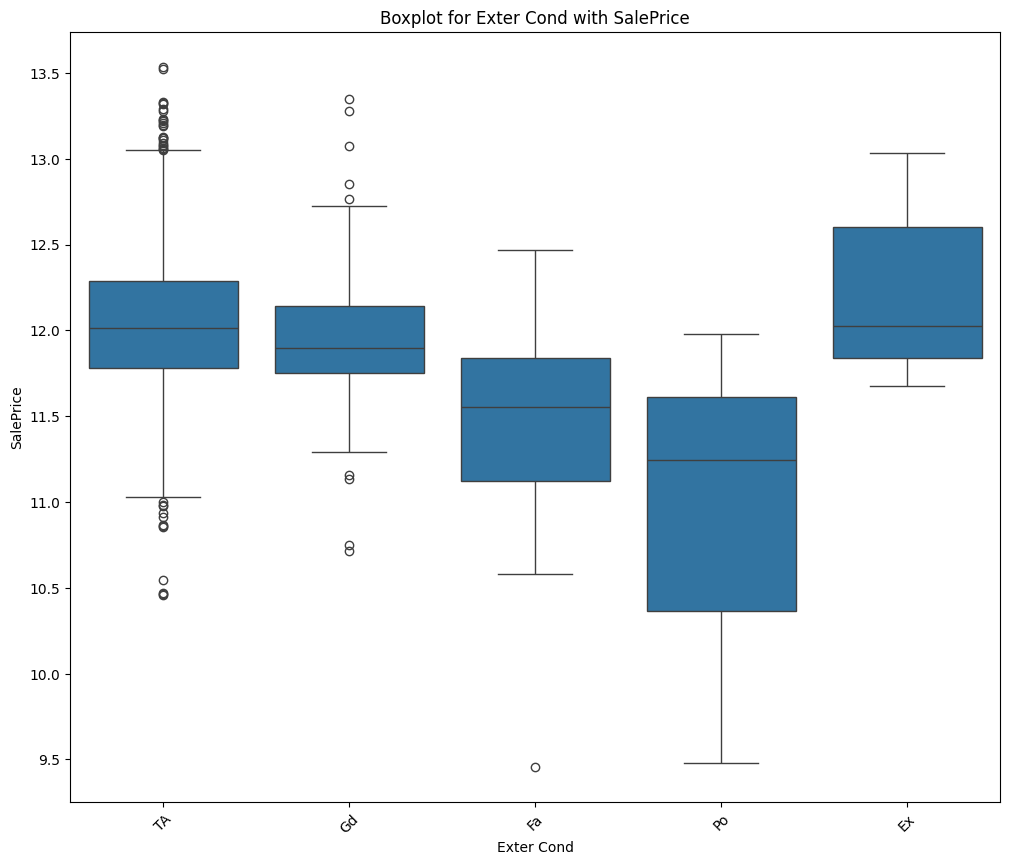

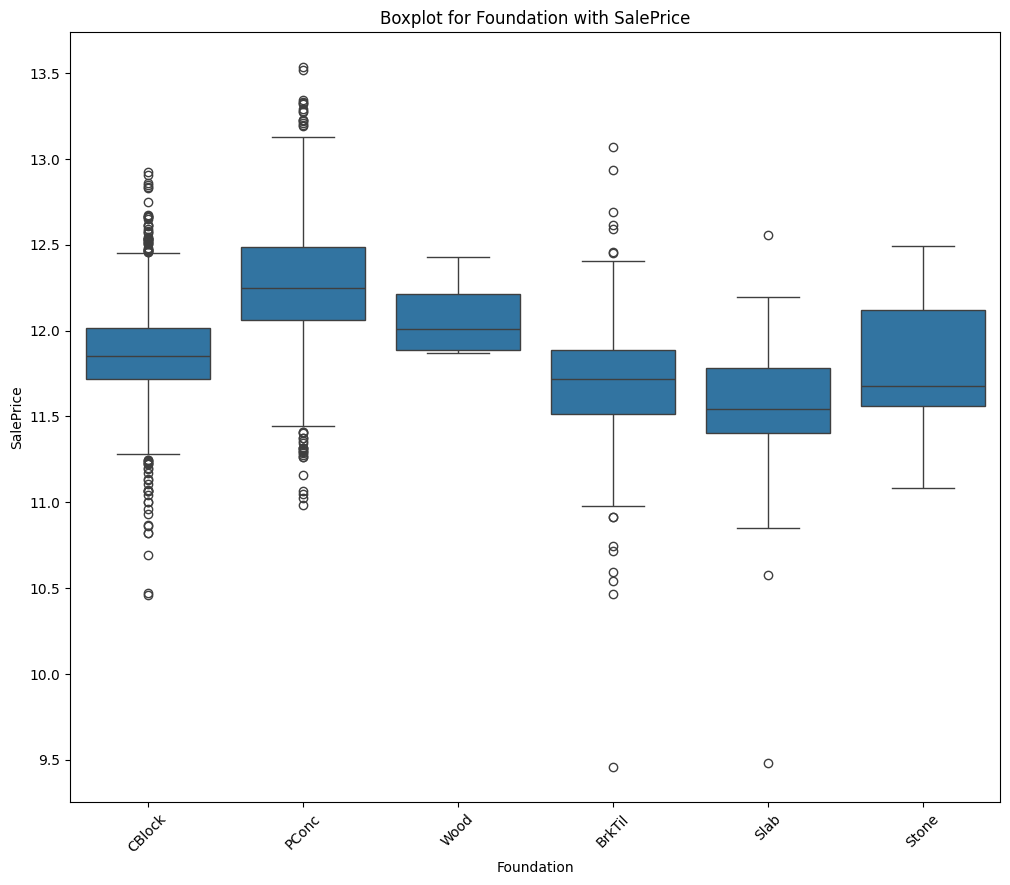

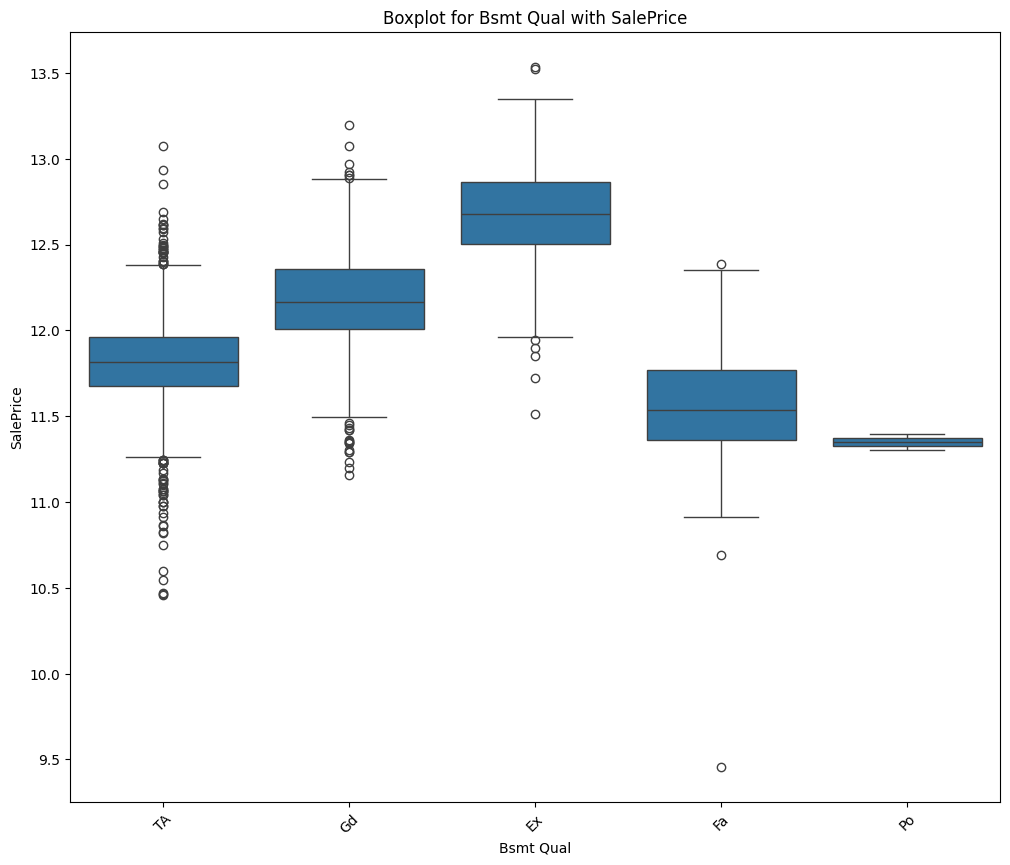

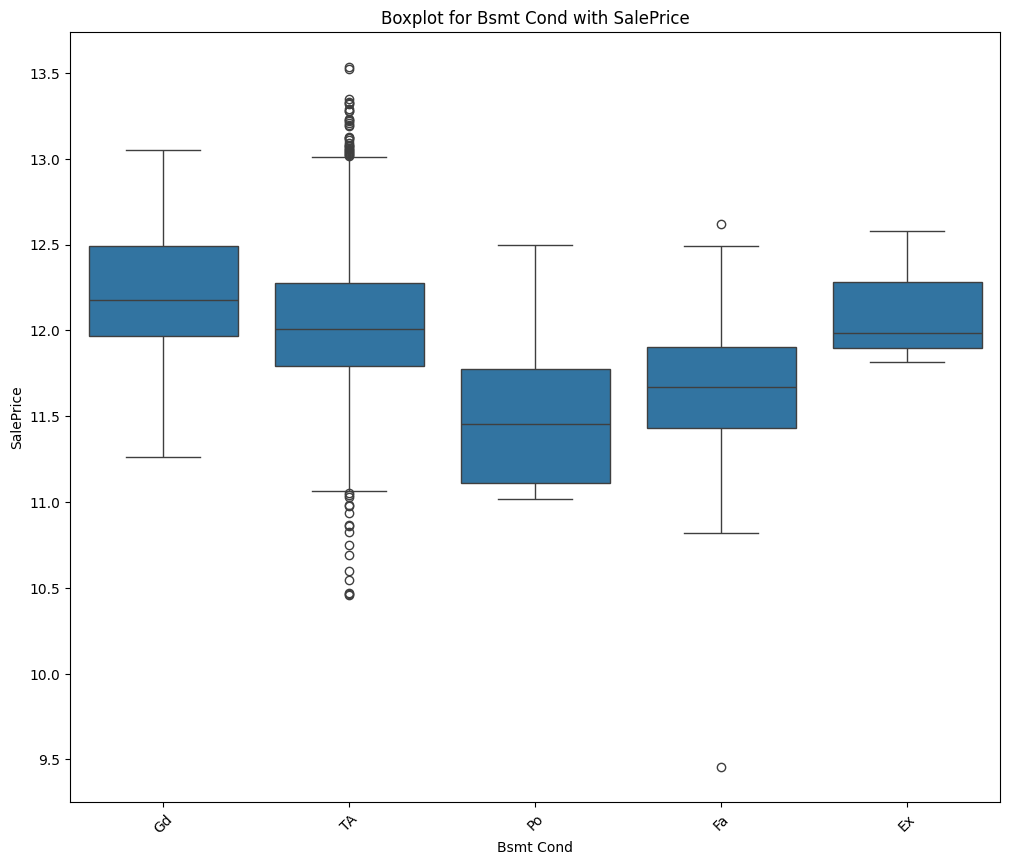

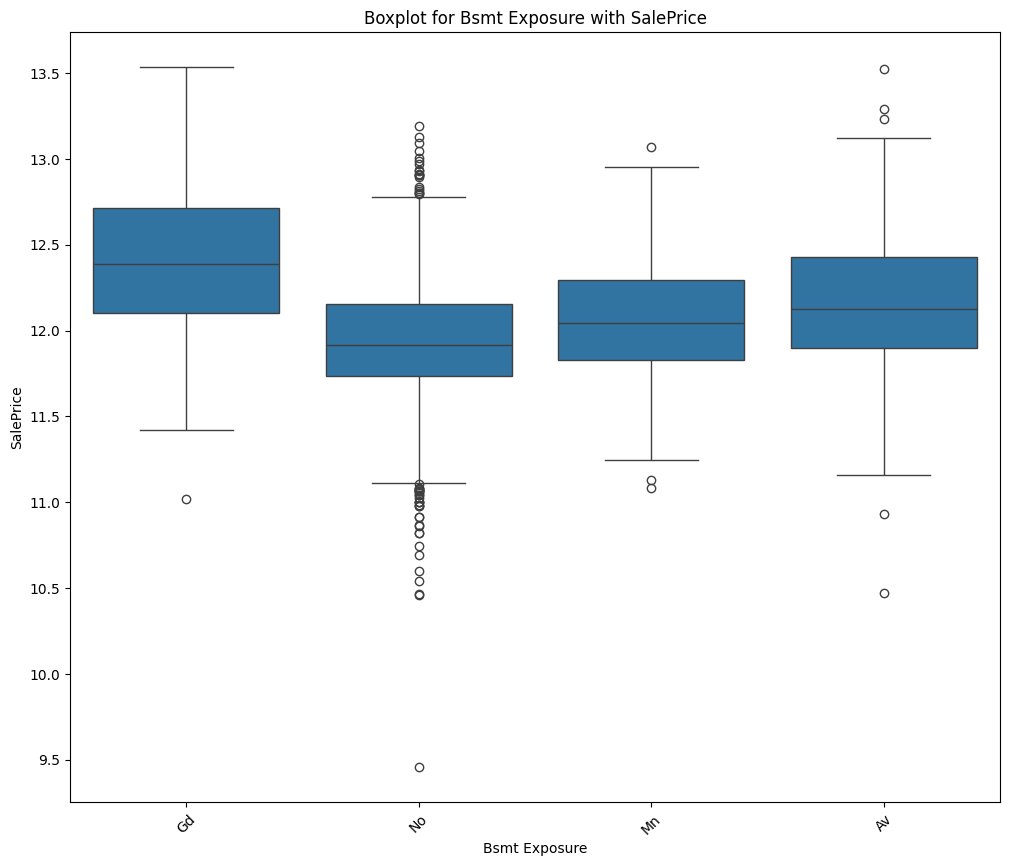

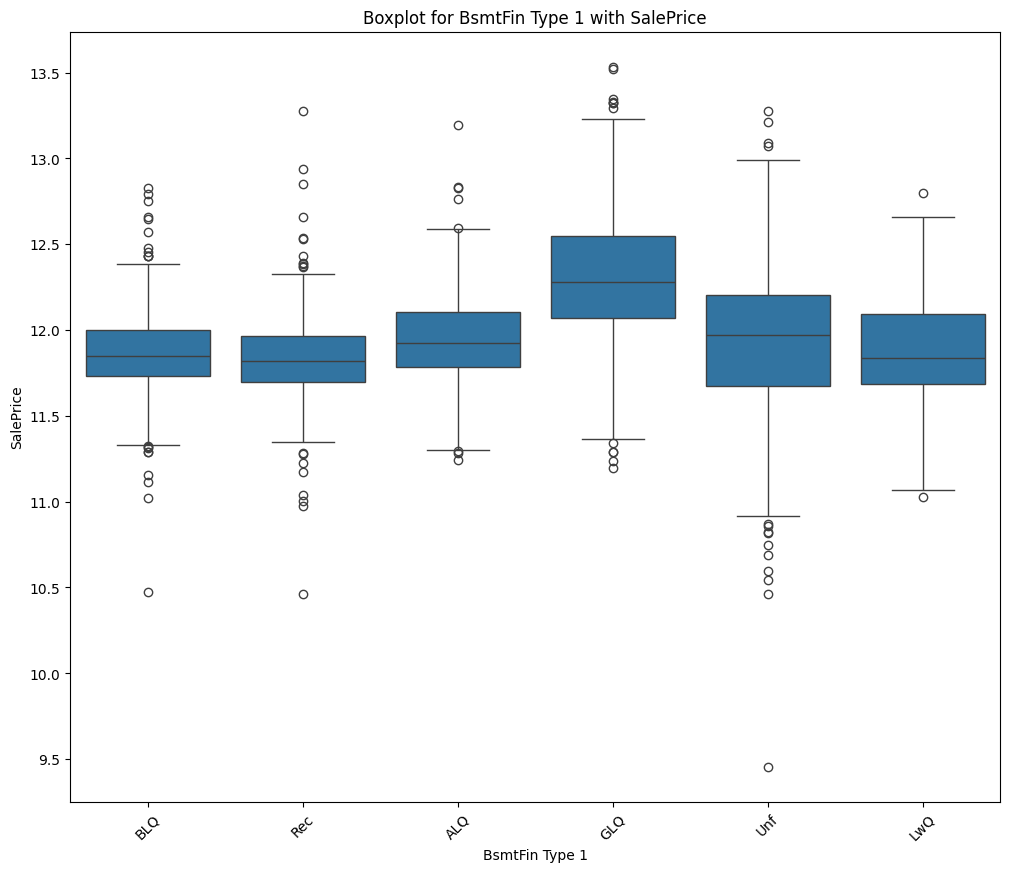

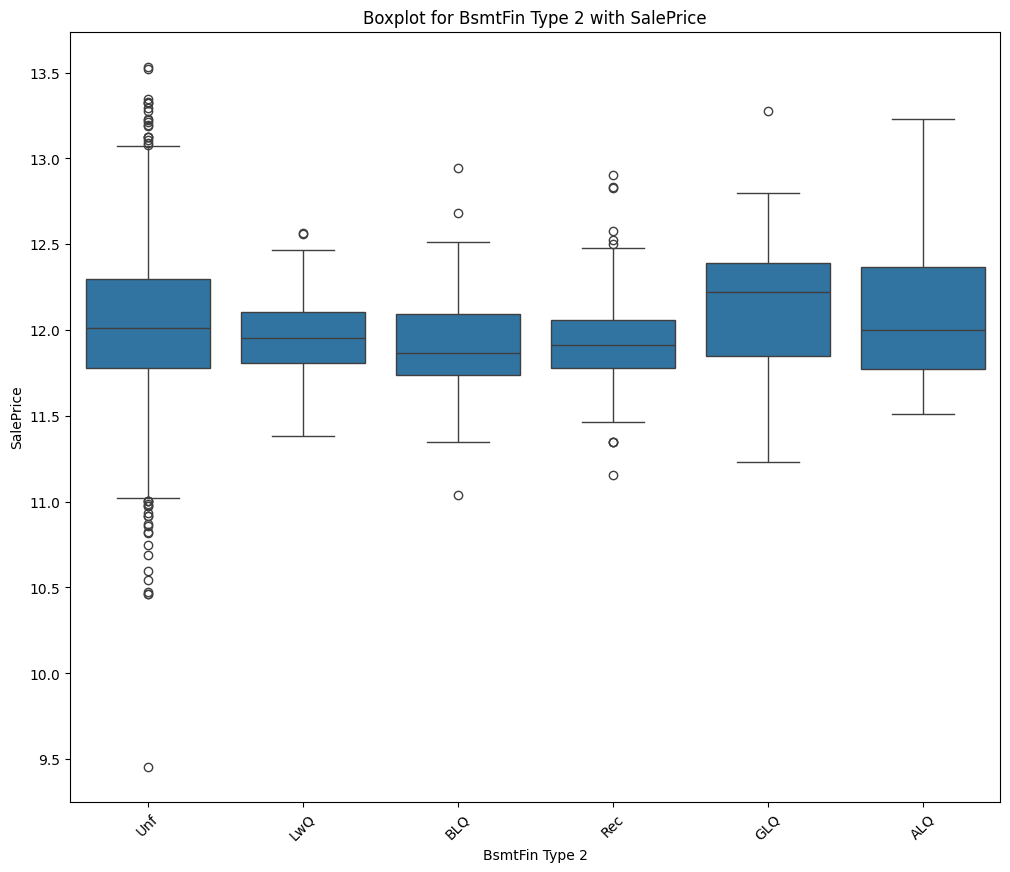

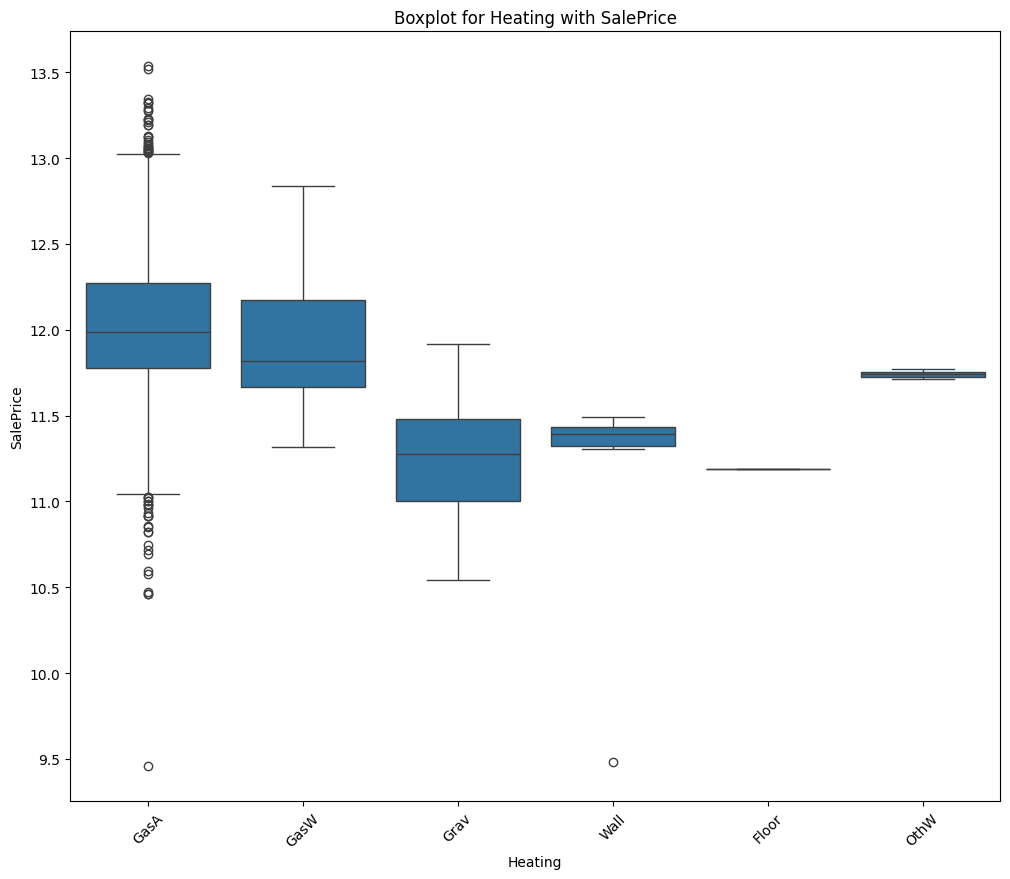

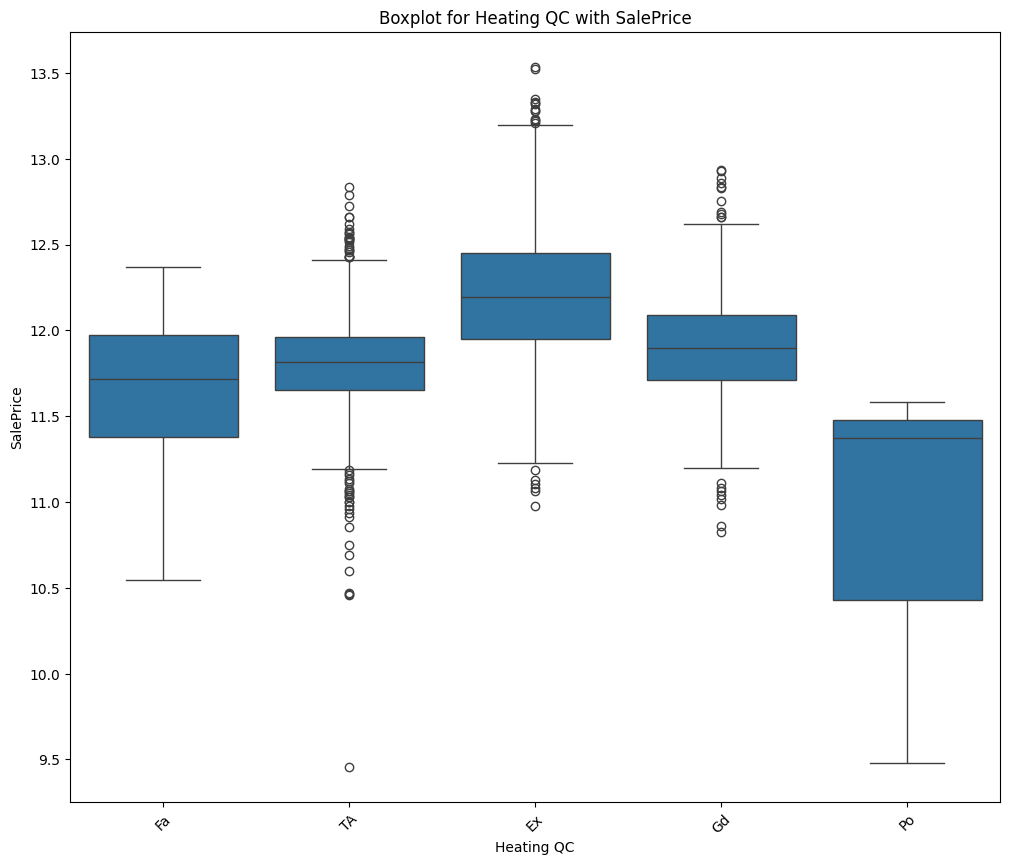

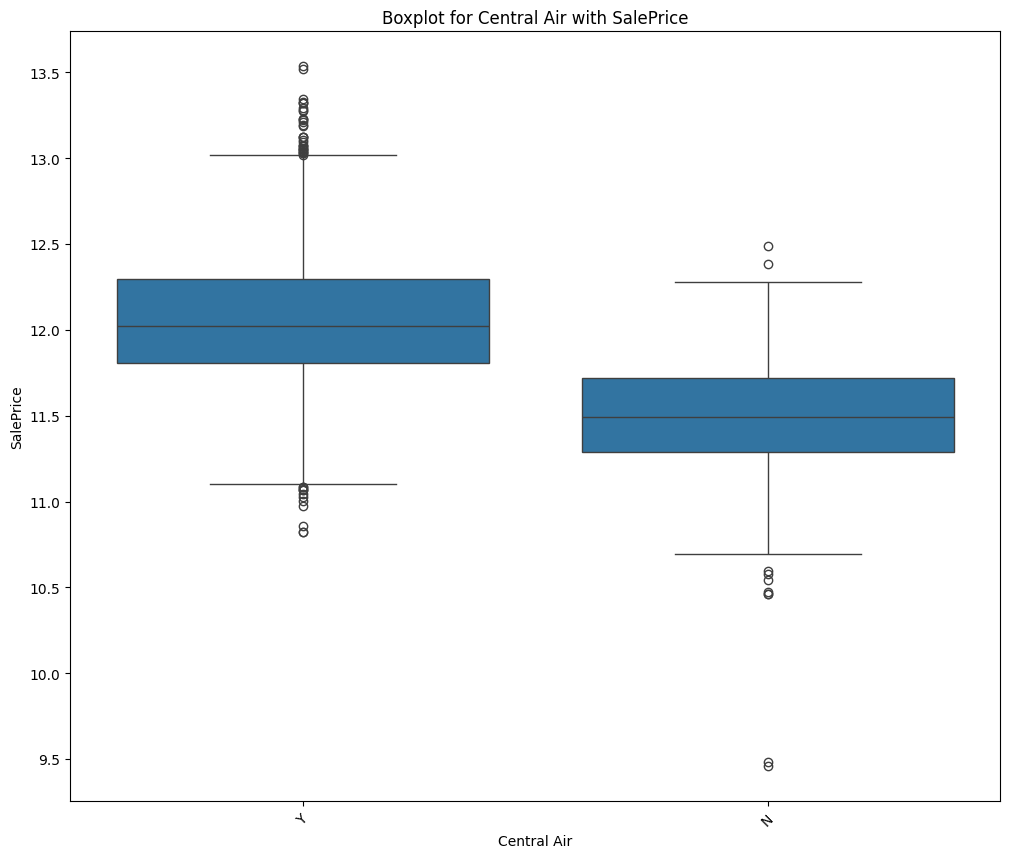

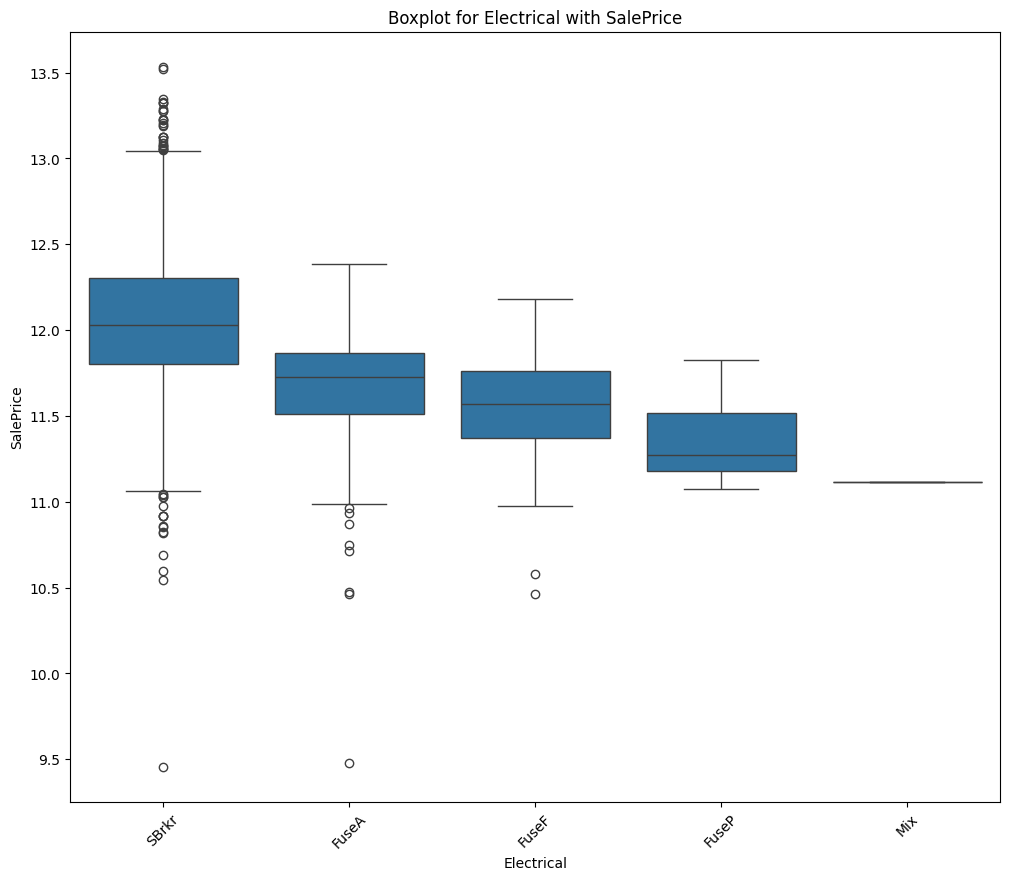

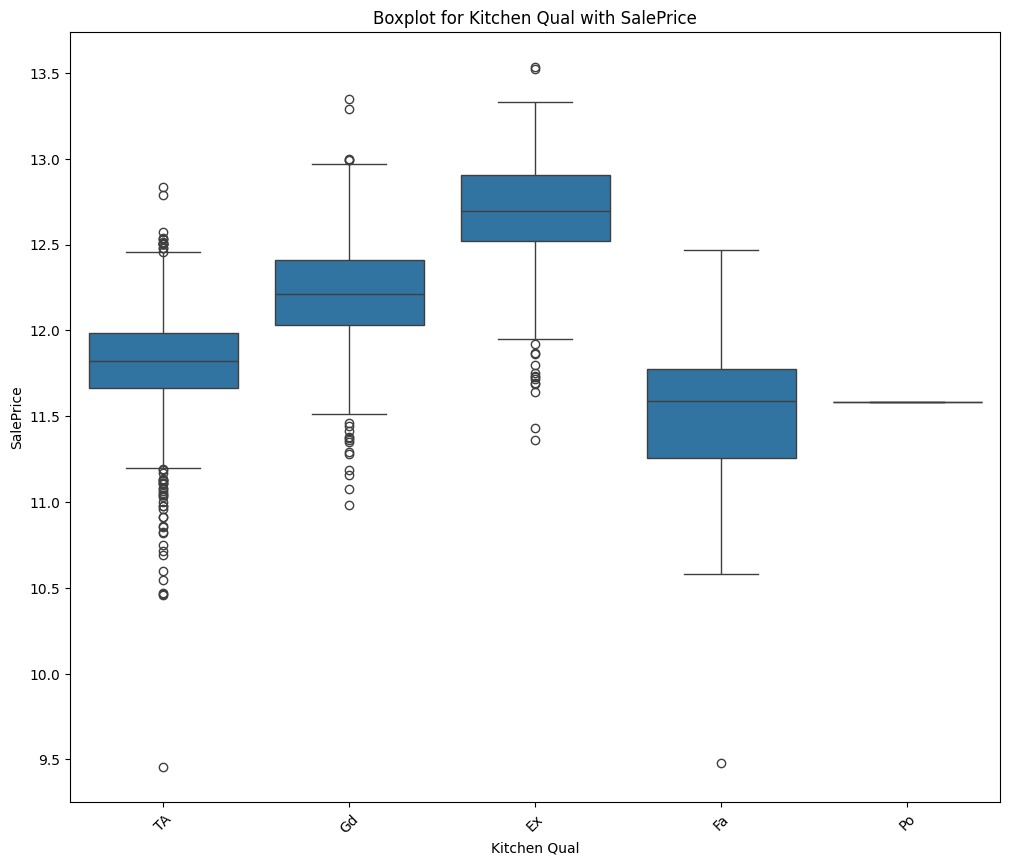

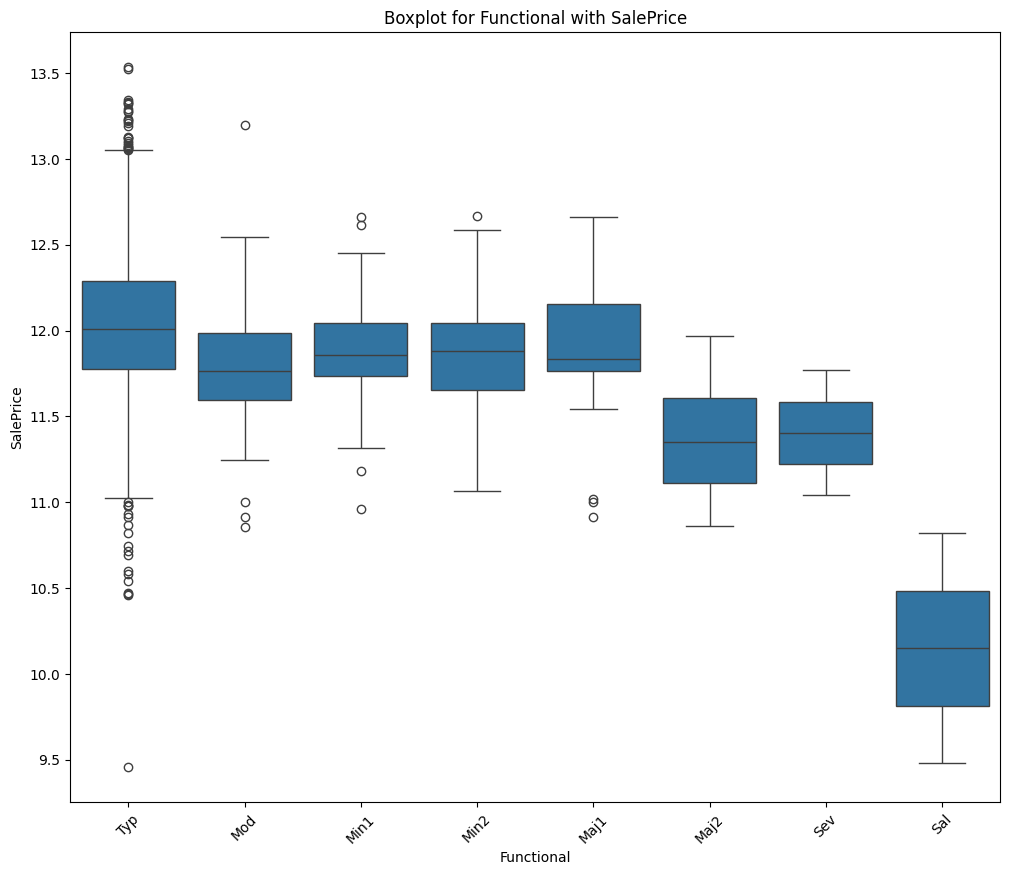

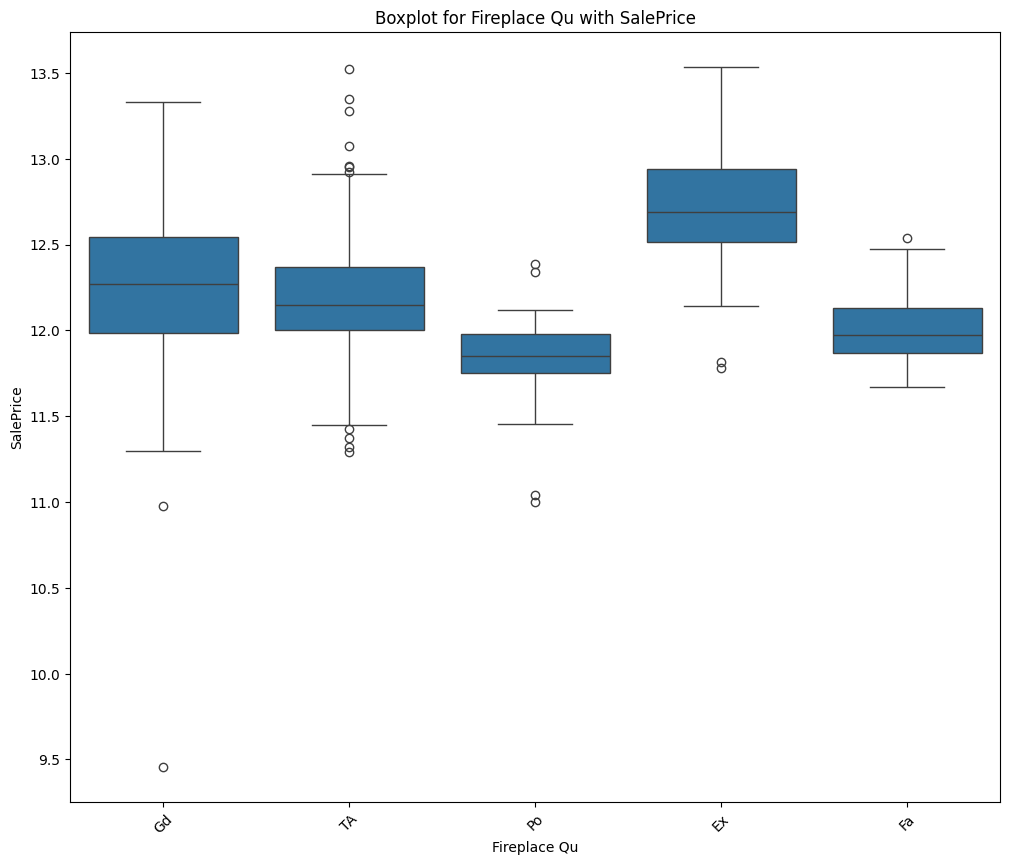

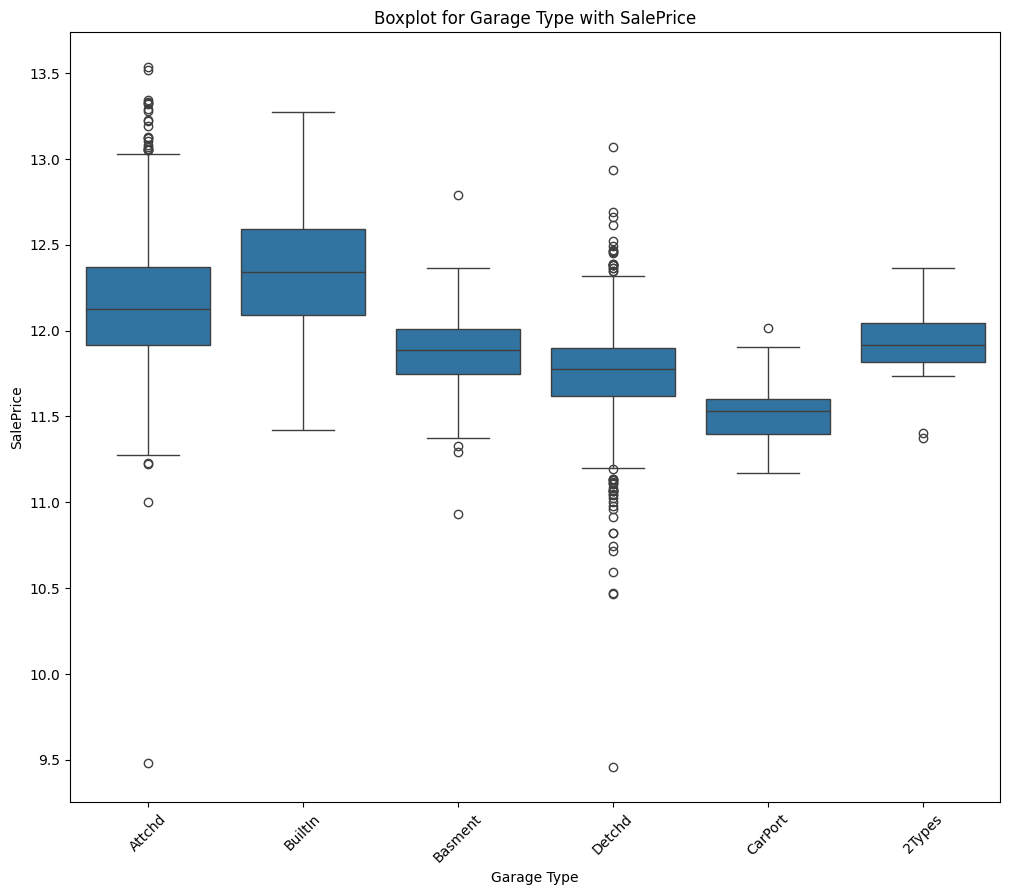

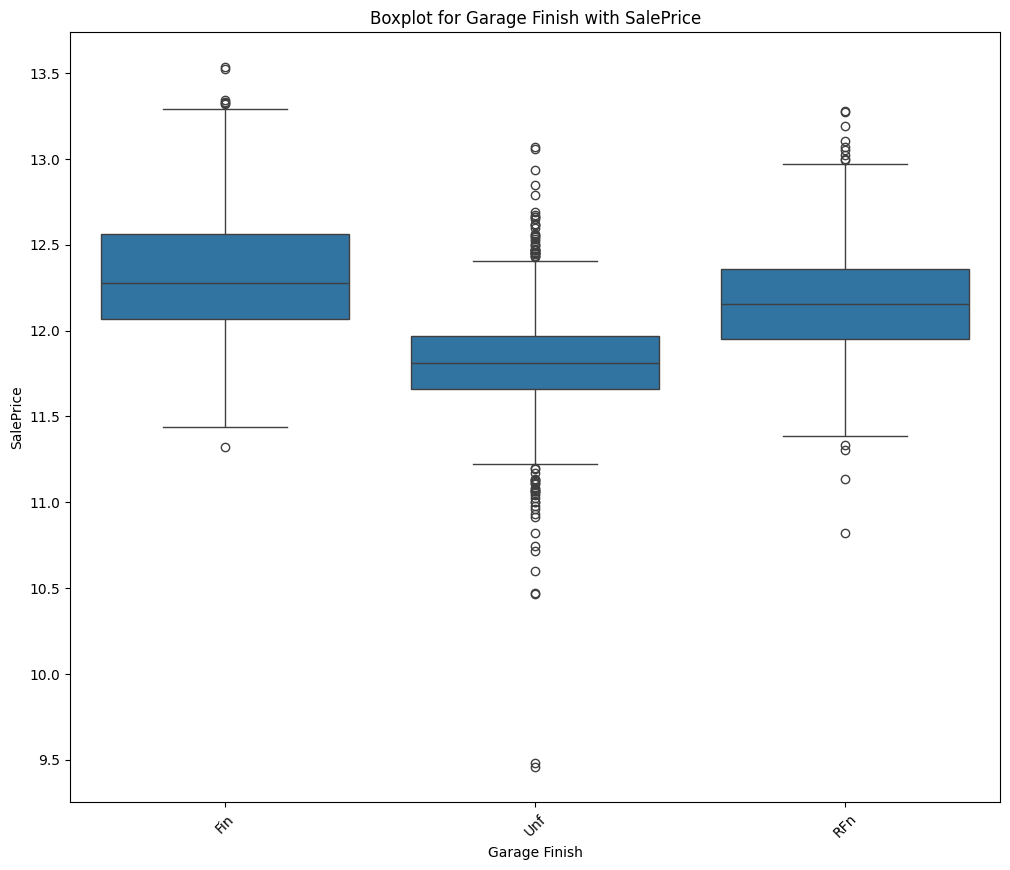

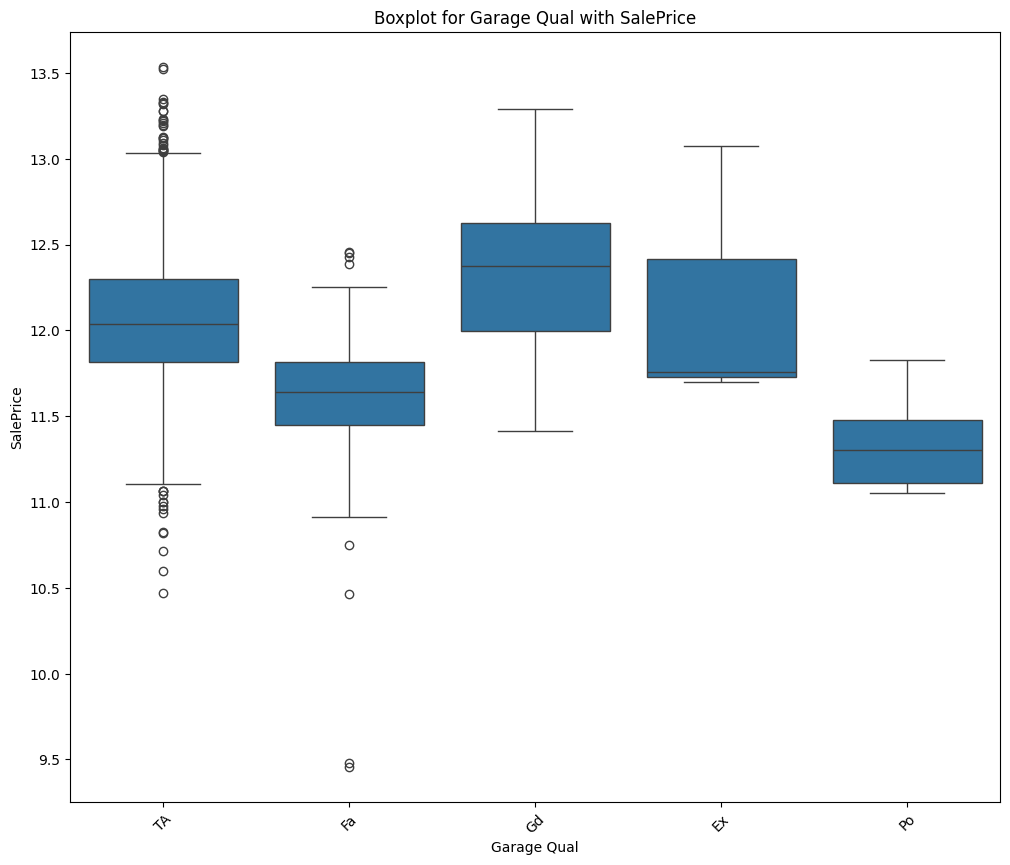

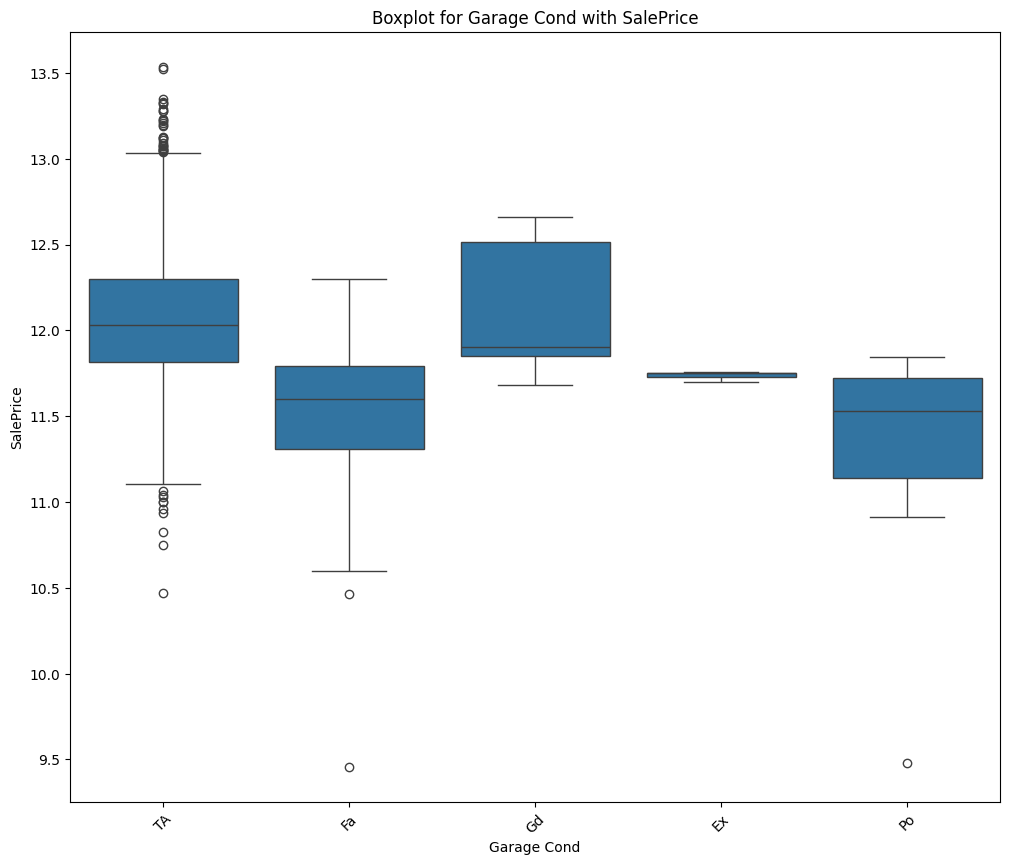

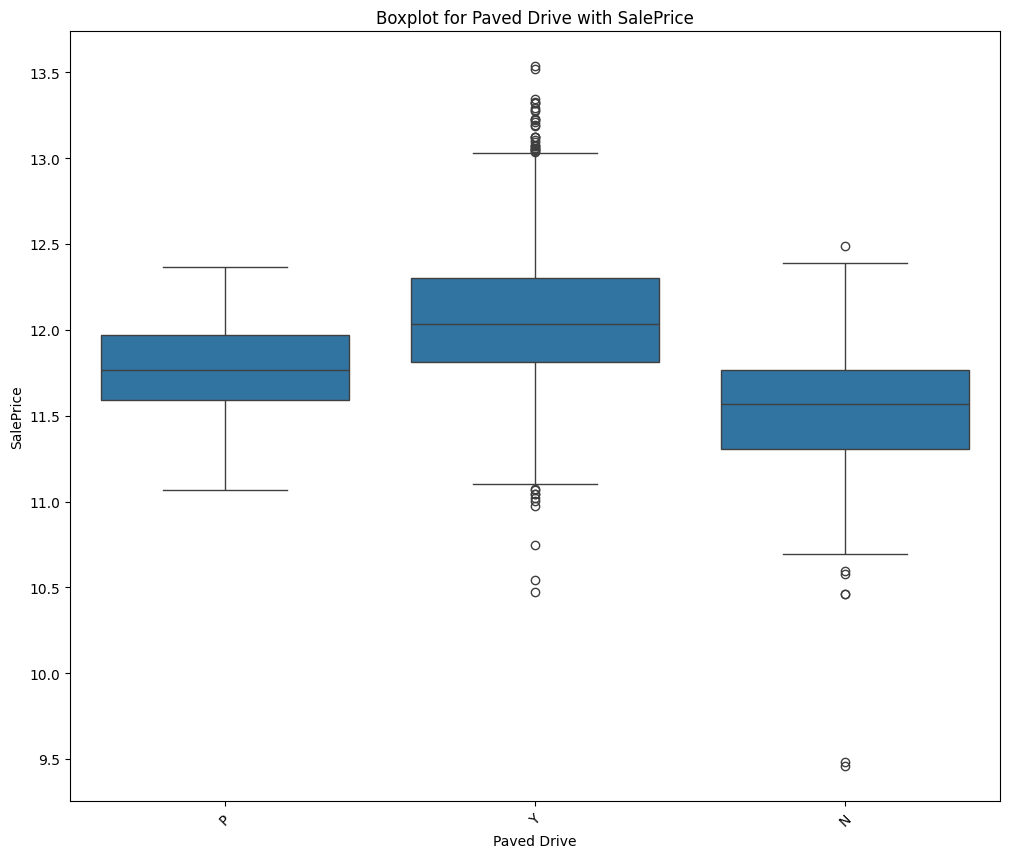

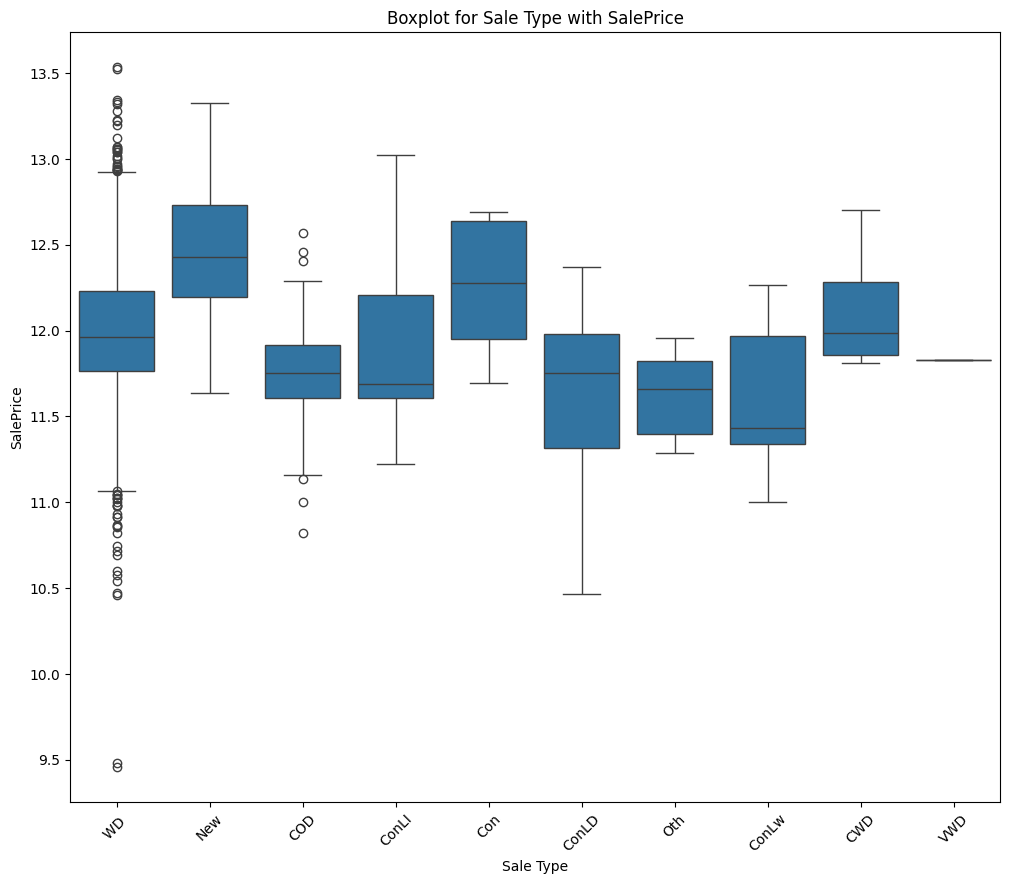

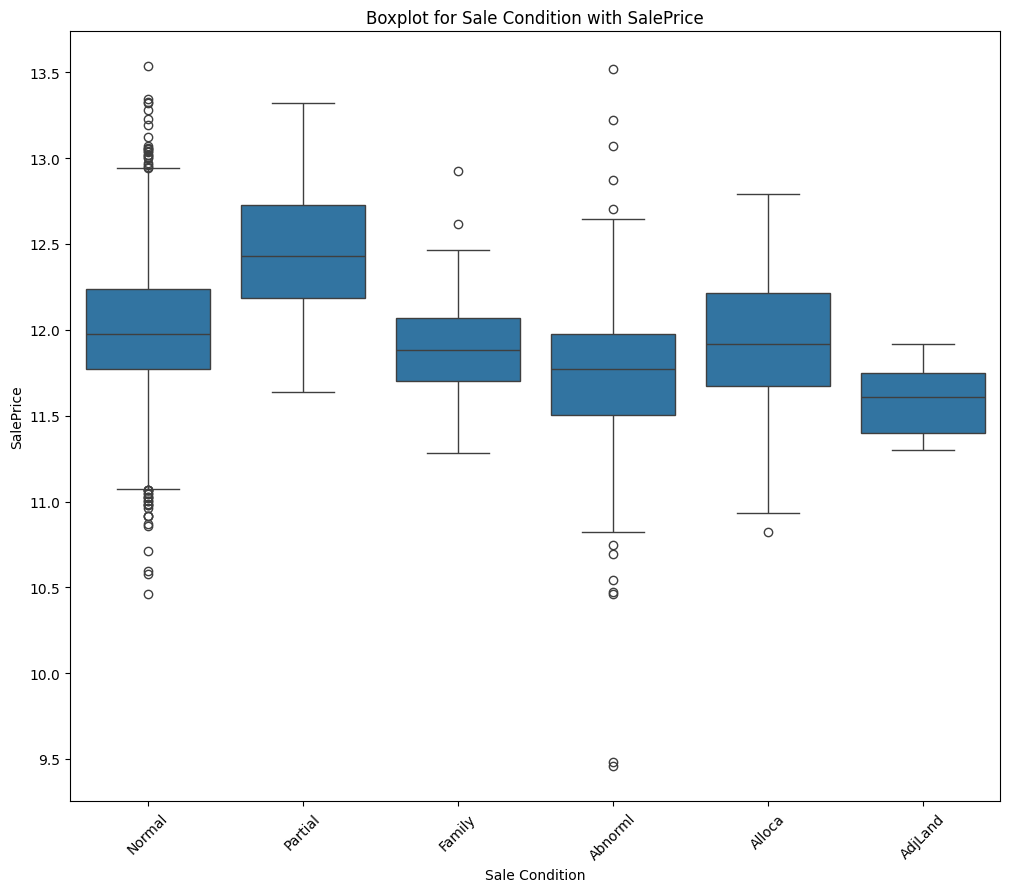

In [24]:
categorical_cols
for items in categorical_cols:
    plt.figure(figsize=(12,10))
    sns.boxplot(data, x=items, y="SalePrice")
    plt.title(f"Boxplot for {items} with SalePrice")
    plt.ylabel("SalePrice")
    plt.xlabel(items)
    plt.xticks(rotation=45)
    plt.show()

### HYPOTHESIS TESTING

In [26]:
correlations = data[numerical_cols].corrwith(data['SalePrice']).sort_values(ascending=False)

In [27]:
strong_corr = correlations[abs(correlations) > 0.5]

In [28]:
strong_corr

Overall Qual      0.825645
Gr Liv Area       0.695863
Garage Cars       0.675318
Garage Area       0.651132
Total Bsmt SF     0.625099
Year Built        0.615485
1st Flr SF        0.602629
Year Remod/Add    0.586153
Garage Yr Blt     0.580502
Full Bath         0.577335
dtype: float64

In [29]:
weak_corr = correlations[abs(correlations) < 0.1]
weak_corr

Pool Area          0.054403
3Ssn Porch         0.040248
Mo Sold            0.038960
BsmtFin SF 2       0.018332
Misc Val          -0.008718
Bsmt Half Bath    -0.020954
Yr Sold           -0.033131
Low Qual Fin SF   -0.044842
Overall Cond      -0.048294
MS SubClass       -0.070744
dtype: float64

In [30]:
f_scores =[]
p_values = []

for col in categorical_cols:
    temp_data = data[[col, 'SalePrice']].dropna()
    
    # Encode categorical variable
    le = LabelEncoder()
    encoded = le.fit_transform(temp_data[col])
    
    # Calculate F-statistic and p-value
    f_score, p_value = f_classif(encoded.reshape(-1, 1), temp_data['SalePrice'])
    f_scores.append(f_score[0])
    p_values.append(p_value[0])

cat_feature_importance = pd.DataFrame({
    'Feature': categorical_cols,
    'F_Score': f_scores,
    'P_Value': p_values
}).sort_values('F_Score', ascending=False)

In [31]:
cat_feature_importance.head()

,Feature,F_Score,P_Value
17,Exter Qual,4.708601,0.0
1,Street,4.294796,0.0
20,Bsmt Qual,3.092042,0.0
29,Kitchen Qual,2.984350,0.0
33,Garage Finish,2.361419,0.0


In [32]:
cat_feature_importance

,Feature,F_Score,P_Value
17,Exter Qual,4.708601,0.000000e+00
1,Street,4.294796,0.000000e+00
20,Bsmt Qual,3.092042,0.000000e+00
29,Kitchen Qual,2.984350,0.000000e+00
33,Garage Finish,2.361419,0.000000e+00
9,Condition 2,1.986634,3.584428e-38
0,MS Zoning,1.877087,2.305922e-32
27,Central Air,1.755954,3.501616e-26
19,Foundation,1.743334,1.481177e-25
25,Heating,1.677843,2.282574e-22


In [33]:
insignificant = cat_feature_importance[cat_feature_importance['P_Value'] > 0.05]

In [34]:
insignificant

,Feature,F_Score,P_Value
21,Bsmt Cond,1.085571,0.067928
23,BsmtFin Type 1,1.047101,0.201295
15,Exterior 2nd,1.034919,0.263155
14,Exterior 1st,1.022006,0.343254
10,Bldg Type,1.004070,0.468263
5,Lot Config,0.974090,0.682138
18,Exter Cond,0.973266,0.687619
8,Condition 1,0.929127,0.908719
30,Functional,0.858068,0.997194
24,BsmtFin Type 2,0.789703,0.999986


In [35]:
# Check these specific features that are often important
important_cats = ['Neighborhood', 'MS Zoning', 'Heating QC', 'Central Air', 'Sale Type']
for col in important_cats:
    if col in cat_feature_importance['Feature'].values:
        score = cat_feature_importance[cat_feature_importance['Feature'] == col]
        print(f"{col}: F-score = {score['F_Score'].values[0]:.3f}, p = {score['P_Value'].values[0]:.4f}")

Neighborhood: F-score = 1.196, p = 0.0005
MS Zoning: F-score = 1.877, p = 0.0000
Heating QC: F-score = 1.551, p = 0.0000
Central Air: F-score = 1.756, p = 0.0000
Sale Type: F-score = 1.094, p = 0.0487


In [36]:
numerical_cols = [col for col in numerical_cols if col not in ['Order', 'PID', 'SalePrice']]

correlations = {}
for col in numerical_cols:
    # Handle missing values by dropping
    corr = data[[col, 'SalePrice']].dropna()[col].corr(data[[col, 'SalePrice']].dropna()['SalePrice'])
    correlations[col] = corr

corr_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Correlation'])
corr_df = corr_df.sort_values('Correlation', ascending=False)

In [37]:
corr_df.head()

,Feature,Correlation
3,Overall Qual,0.825645
15,Gr Liv Area,0.695863
25,Garage Cars,0.675318
26,Garage Area,0.651132
11,Total Bsmt SF,0.625099


In [38]:
# Create a list of features to keep
features_to_keep = []

# Add numerical features with |correlation| > 0.3
strong_num_features = corr_df[abs(corr_df['Correlation']) > 0.3]['Feature'].tolist()
features_to_keep.extend(strong_num_features)

# Add significant categorical features (p-value <= 0.05)
significant_cat = cat_feature_importance[cat_feature_importance['P_Value'] <= 0.05]['Feature'].tolist()
features_to_keep.extend(significant_cat)

# Remove duplicates and add target
features_to_keep = list(set(features_to_keep))
features_to_keep.append('SalePrice')

print(f"Selected {len(features_to_keep)} features for modeling:")
print(features_to_keep[:20])  # Show first 20

# Create reduced dataset
data_reduced = data[features_to_keep]
print(f"\nOriginal dataset: {data.shape}")
print(f"Reduced dataset: {data_reduced.shape}")

Selected 48 features for modeling:
['Lot Shape', 'Wood Deck SF', 'Sale Condition', 'Year Built', 'MS Zoning', 'Utilities', 'Gr Liv Area', 'Mas Vnr Type', 'Street', 'Total Bsmt SF', 'Foundation', 'Fireplaces', 'Bsmt Exposure', 'Condition 2', 'Heating QC', 'Lot Frontage', 'Heating', 'BsmtFin SF 1', 'Full Bath', 'Half Bath']

Original dataset: (2930, 78)
Reduced dataset: (2930, 48)


### DATA CLEANING: IMPUTATION

In [40]:
data.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config',
       'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type',
       'House Style', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st',
       'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2',
       'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air',
       'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
       'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu',
       'Garage Type', 'Garage Yr Blt', 'Garage Finish'

In [41]:
data['Remodeled'] = (data['Year Remod/Add'] != data['Year Built']).astype(int)
data['TotalSF'] = data['Total Bsmt SF'] + data['1st Flr SF'] + data['2nd Flr SF']
data['HouseAge'] = data['Yr Sold'] - data['Year Built']

In [159]:
data['Remodeled']

0       0
1       0
2       0
3       0
4       1
       ..
2925    0
2926    0
2927    0
2928    1
2929    1
Name: Remodeled, Length: 2930, dtype: int32

In [161]:
X = data.drop(["SalePrice", "PID", 'Order'], axis=1)
y = data['SalePrice']

In [164]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [166]:
numer_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categ_cols = X_train.select_dtypes(include=['object']).columns

In [169]:
numer_cols.sort_values()

Index(['1st Flr SF', '2nd Flr SF', '3Ssn Porch', 'Bedroom AbvGr',
       'Bsmt Full Bath', 'Bsmt Half Bath', 'Bsmt Unf SF', 'BsmtFin SF 1',
       'BsmtFin SF 2', 'Enclosed Porch', 'Fireplaces', 'Full Bath',
       'Garage Area', 'Garage Cars', 'Garage Yr Blt', 'Gr Liv Area',
       'Half Bath', 'HouseAge', 'Kitchen AbvGr', 'Lot Area', 'Lot Frontage',
       'Low Qual Fin SF', 'MS SubClass', 'Mas Vnr Area', 'Misc Val', 'Mo Sold',
       'Open Porch SF', 'Overall Cond', 'Overall Qual', 'Pool Area',
       'Screen Porch', 'TotRms AbvGrd', 'Total Bsmt SF', 'TotalSF',
       'Wood Deck SF', 'Year Built', 'Year Remod/Add', 'Yr Sold'],
      dtype='object')

In [171]:
categ_cols.sort_values()

Index(['Bldg Type', 'Bsmt Cond', 'Bsmt Exposure', 'Bsmt Qual',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Central Air', 'Condition 1',
       'Condition 2', 'Electrical', 'Exter Cond', 'Exter Qual', 'Exterior 1st',
       'Exterior 2nd', 'Fireplace Qu', 'Foundation', 'Functional',
       'Garage Cond', 'Garage Finish', 'Garage Qual', 'Garage Type', 'Heating',
       'Heating QC', 'House Style', 'Kitchen Qual', 'Land Contour',
       'Land Slope', 'Lot Config', 'Lot Shape', 'MS Zoning', 'Mas Vnr Type',
       'Neighborhood', 'Paved Drive', 'Roof Matl', 'Roof Style',
       'Sale Condition', 'Sale Type', 'Street', 'Utilities'],
      dtype='object')

In [179]:
data2 = pd.concat([data[numer_cols], data[categ_cols],data["Remodeled"], data["SalePrice"]], axis=1)

In [181]:
data2.head()

,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,...,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition,Remodeled,SalePrice
0,20,141.0,31770,6,5,1960,1960,112.0,639.0,0.0,...,Gd,Attchd,Fin,TA,TA,P,WD,Normal,0,12.278398
1,20,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,...,NaN,Attchd,Unf,TA,TA,Y,WD,Normal,0,11.561725
2,20,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,...,NaN,Attchd,Unf,TA,TA,Y,WD,Normal,0,12.055256
3,20,93.0,11160,7,5,1968,1968,0.0,1065.0,0.0,...,TA,Attchd,Fin,TA,TA,Y,WD,Normal,0,12.404928
4,60,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,...,TA,Attchd,Fin,TA,TA,Y,WD,Normal,1,12.154258


In [183]:
data2['Remodeled']


0       0
1       0
2       0
3       0
4       1
       ..
2925    0
2926    0
2927    0
2928    1
2929    1
Name: Remodeled, Length: 2930, dtype: int32

In [189]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 79 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2930 non-null   int64  
 1   Lot Frontage     2440 non-null   float64
 2   Lot Area         2930 non-null   int64  
 3   Overall Qual     2930 non-null   int64  
 4   Overall Cond     2930 non-null   int64  
 5   Year Built       2930 non-null   int64  
 6   Year Remod/Add   2930 non-null   int64  
 7   Mas Vnr Area     2907 non-null   float64
 8   BsmtFin SF 1     2929 non-null   float64
 9   BsmtFin SF 2     2929 non-null   float64
 10  Bsmt Unf SF      2929 non-null   float64
 11  Total Bsmt SF    2929 non-null   float64
 12  1st Flr SF       2930 non-null   int64  
 13  2nd Flr SF       2930 non-null   int64  
 14  Low Qual Fin SF  2930 non-null   int64  
 15  Gr Liv Area      2930 non-null   int64  
 16  Bsmt Full Bath   2928 non-null   float64
 17  Bsmt Half Bath

In [187]:
data2.to_csv("AmesHousingUpdated.csv")

In [48]:
missing_val =[]
for cols in data.columns:
    missing_cols =data[cols].isnull().sum()
    if missing_cols > 0:
        missing = missing_cols / len(data) * 100
        missing_val.append(cols)
        print(f'{cols}: {missing_cols} missing, {missing:.2f}')

Lot Frontage: 490 missing, 16.72
Mas Vnr Type: 1775 missing, 60.58
Mas Vnr Area: 23 missing, 0.78
Bsmt Qual: 80 missing, 2.73
Bsmt Cond: 80 missing, 2.73
Bsmt Exposure: 83 missing, 2.83
BsmtFin Type 1: 80 missing, 2.73
BsmtFin SF 1: 1 missing, 0.03
BsmtFin Type 2: 81 missing, 2.76
BsmtFin SF 2: 1 missing, 0.03
Bsmt Unf SF: 1 missing, 0.03
Total Bsmt SF: 1 missing, 0.03
Electrical: 1 missing, 0.03
Bsmt Full Bath: 2 missing, 0.07
Bsmt Half Bath: 2 missing, 0.07
Fireplace Qu: 1422 missing, 48.53
Garage Type: 157 missing, 5.36
Garage Yr Blt: 159 missing, 5.43
Garage Finish: 159 missing, 5.43
Garage Cars: 1 missing, 0.03
Garage Area: 1 missing, 0.03
Garage Qual: 159 missing, 5.43
Garage Cond: 159 missing, 5.43
TotalSF: 1 missing, 0.03


In [49]:
missing_val

['Lot Frontage',
 'Mas Vnr Type',
 'Mas Vnr Area',
 'Bsmt Qual',
 'Bsmt Cond',
 'Bsmt Exposure',
 'BsmtFin Type 1',
 'BsmtFin SF 1',
 'BsmtFin Type 2',
 'BsmtFin SF 2',
 'Bsmt Unf SF',
 'Total Bsmt SF',
 'Electrical',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Fireplace Qu',
 'Garage Type',
 'Garage Yr Blt',
 'Garage Finish',
 'Garage Cars',
 'Garage Area',
 'Garage Qual',
 'Garage Cond',
 'TotalSF']

In [50]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [51]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    
])

In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer,numer_cols),
        ('cat', categorical_transformer, categ_cols)
    ]
)

In [53]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [54]:
models = {
    "Linear Regression": {"model": LinearRegression()},
    "Ridge": {"model": Ridge(alpha=0.5)}
}

In [55]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [56]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area',
       'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       '1st Flr SF', '2nd Flr SF', '...
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Sale Type', 'Sale Condition'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [57]:
predictions = pipeline.predict(X_test)

In [58]:
mean_squared_error(y_test, predictions)

0.020185781082381234

In [59]:
np.sqrt(mean_squared_error(y_test, predictions))

0.1420766732520903